In [1]:
import warnings
warnings.filterwarnings("ignore")

from tqdm import tqdm
import pandas as pd
import scanpy as sc
import anndata as ad
import numpy as np
import seaborn as sns
import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
import rapids_singlecell as rsc

sc.settings.verbosity = 3               # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_version_and_date()

Running Scanpy 1.11.4, on 2026-08-27 09:19.


In [2]:
plot_folder = "/media/synology/Huijuan/Plots/IPF_subsets/IPF_paper/"
sc.settings.figdir = plot_folder
sc.set_figure_params(dpi=100, dpi_save=300, vector_friendly=True)

plt.rcParams["figure.figsize"] = (5, 5)
plt.rcParams.update({'font.size': 14})
plt.rcParams['pdf.fonttype'] = 42
sns.set_style("ticks")

## Define relative frequency function

In [3]:
def calc_relFreq(a, group_by="cell_type", xlabel="days", condition="batch"):
    freqs = a.obs.groupby(["batch", group_by]).size()
    samples = np.unique(a.obs["batch"])
    ind = a.obs[group_by].cat.categories

    relFreqs = [freqs[ident] / sum(freqs[ident]) for ident in samples]
    relFreqs = pd.DataFrame(relFreqs, columns=ind, index=samples).fillna(0)

    cell_types = {}
    combis = a.obs.groupby(["batch", xlabel]).groups.keys()

    for c in combis:
        cell_types[c[0]] = c[1]
    relFreqs[xlabel] = [cell_types[l] for l in relFreqs.index]

    if condition:
        combis = a.obs.groupby(["batch", condition]).groups.keys()
        for c in combis:
            cell_types[c[0]] = c[1]
        relFreqs[condition] = [cell_types[l] for l in relFreqs.index]

    return relFreqs

In [4]:
def plot_cluster_composition(
    relFreqs,
    xlabel="name",
    figsize=(6, 10),
    width=0.8,
    order=None,
    errbar=None,
    labelsize=15,
    ticksize=13,
    capsize=None,
    margins=(0.02, 0.04),
    cols=None,
    save=None,
):
    """
    Given a relative frequency table, plot the values as a stacked barplot.
    """

    patches = []

    fig, ax = plt.subplots()
    fig.set_size_inches(figsize)

    order = np.unique(relFreqs[xlabel]) if order is None else order
    ci = 95 if errbar else None

    ax.margins(margins[0], margins[1])

    cell_types = np.flip(
        [col for col in relFreqs.columns if col not in ["identifier", xlabel]]
    )

    bars = pd.DataFrame(index=order, data=np.zeros(len(order)))
    plot_data = pd.DataFrame(relFreqs[xlabel])

    for i, typ in enumerate(cell_types):
        sum_up = [
            relFreqs[typ].values[i] + bars.loc[g].values[0]
            for i, g in enumerate(relFreqs[xlabel])
        ]

        plot_data[typ] = sum_up

        bars.iloc[:, 0] = (
            bars.iloc[:, 0]
            + relFreqs[[typ, xlabel]]
            .groupby(xlabel)
            .mean()
            .loc[order, typ]
        )

    for i, typ in enumerate(reversed(cell_types)):
        sns.barplot(
            data=plot_data,
            x=xlabel,
            y=typ,
            order=order,
            ci=ci,
            errcolor="black",
            color=cols[i] if cols is not None else None,
            capsize=capsize,
            ax=ax,
        )

        patches.append(
            mpatches.Patch(
                color=cols[i] if cols is not None else None,
                label=typ,
            )
        )

    ax.set_xlabel(xlabel, size=labelsize)
    ax.set_ylabel("relative frequency", size=labelsize)
    ax.tick_params(labelsize=ticksize)
    ax.set_xticklabels(order, rotation="vertical")

    # Change bar widths
    for bar in ax.patches:
        centre = bar.get_x() + bar.get_width() / 2.0
        bar.set_x(centre - width / 2.0)
        bar.set_width(width)

    plt.legend(
        handles=patches,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        prop={"size": ticksize},
        frameon=False,
    )

    fig.subplots_adjust(right=0.85)

    if save:
        fig.savefig(
            save,
            bbox_inches="tight",
            pad_inches=0.3,
            dpi=300,
        )
        print(f"Saving Figure to {save}")

    plt.show()
    plt.close()

### Load data

In [5]:
object_folder  = "/media/HDD_1/sc_data_objects/FibFoci/" 
adata = sc.read(object_folder + "18082026_snRNA_IPF_annotation_final.h5ad")  
adata

AnnData object with n_obs × n_vars = 63072 × 31116
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'souporcell_assignment', 'souporcell_singlet_posterior', 'souporcell_doublet_posterior', 'souporcell_log_prob_singleton', 'souporcell_log_prob_doublet', 'souporcell_cluster0', 'souporcell_cluster1', 'souporcell_cluster2', 'ident', 'sum', 'detected', 'subsets_Ribo_sum', 'subsets_Ribo_detected', 'subsets_Ribo_percent', 'total', 'scDblFinder.cluster', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.difficulty', 'scDblFinder.cxds_score', 'scDblFinder.mostLikelyOrigin', 'scDblFinder.originAmbiguous', '_scvi_batch', '_scvi_labels', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'S.Score', 'G2M.Score', 'Phase', 'nCount_SCT', 'nFeature_SCT', 'souporcell_cluster3', 'sex', 'batch', 'Level_1', 'Level_2', 'Level_3', 'cell_type', 'severity', 'name', 'meta', 'ashcroft score', 'fibrosis extent', 'surface density'
    var: 'name', 'highly_variable', 

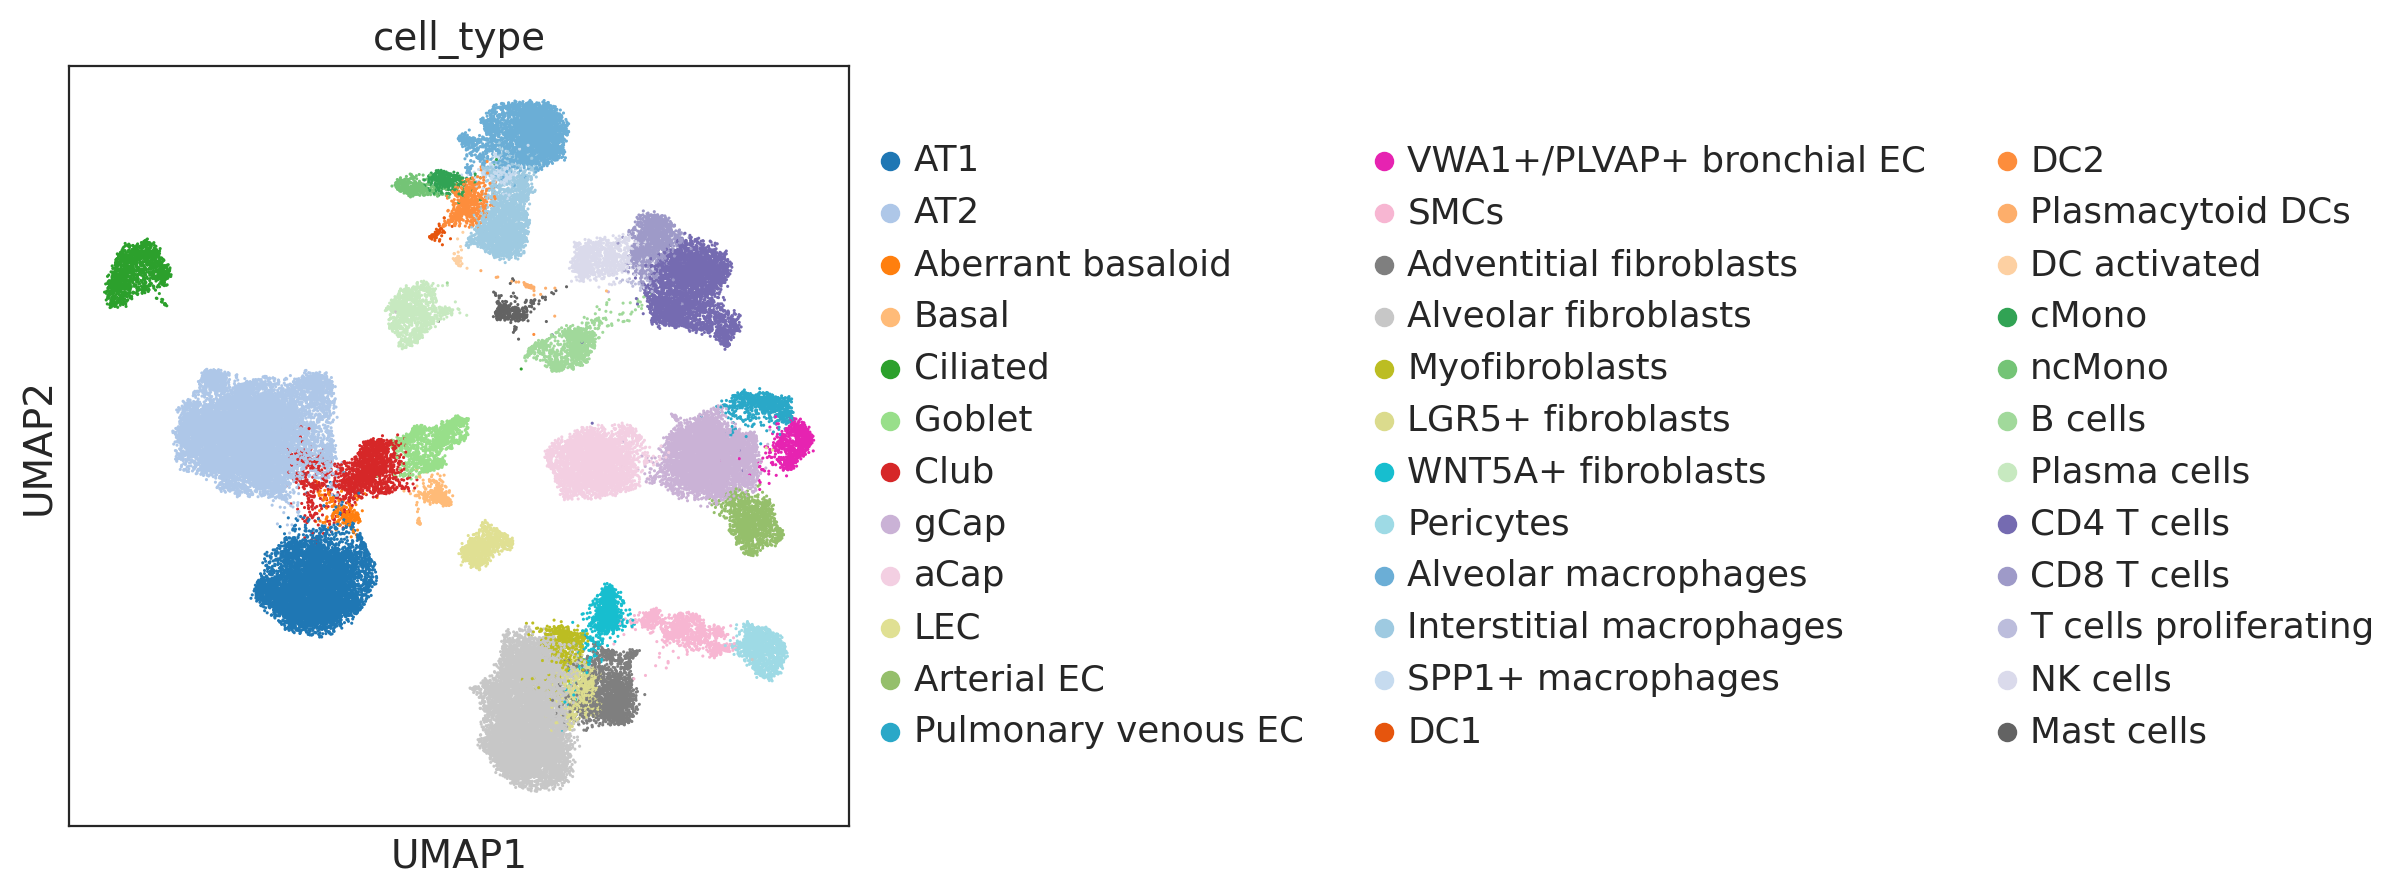

In [6]:
sc.pl.umap(adata, color = ["cell_type"], wspace = 0.2, size=5, frameon= True) 

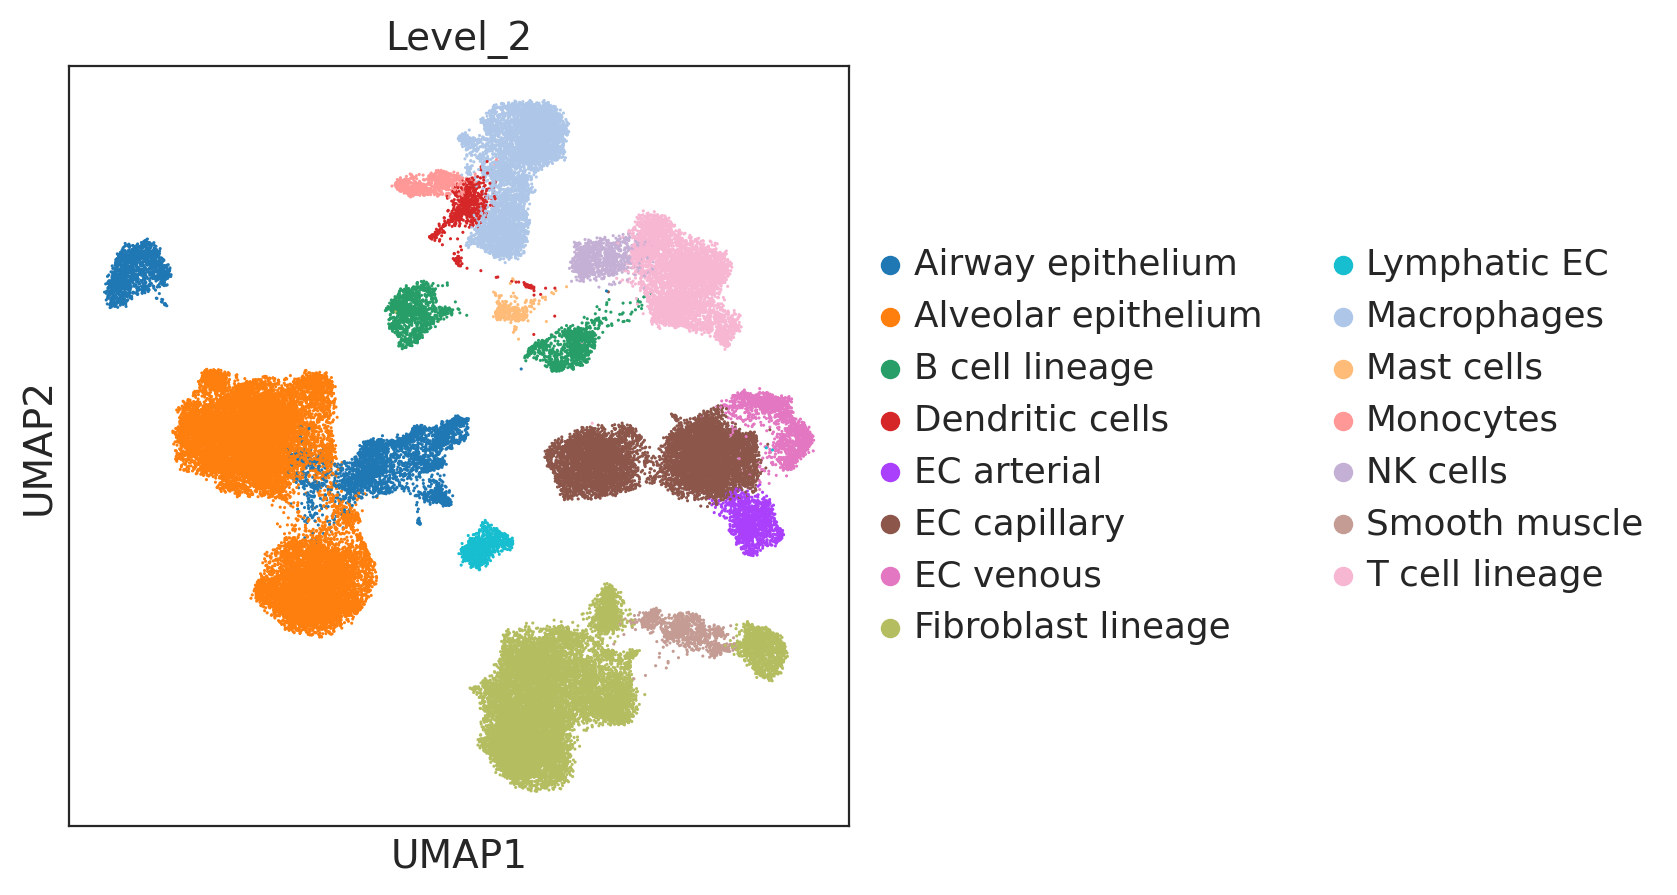

In [7]:
sc.pl.umap(adata, color = ["Level_2"], wspace = 0.2, size=5, frameon= True)

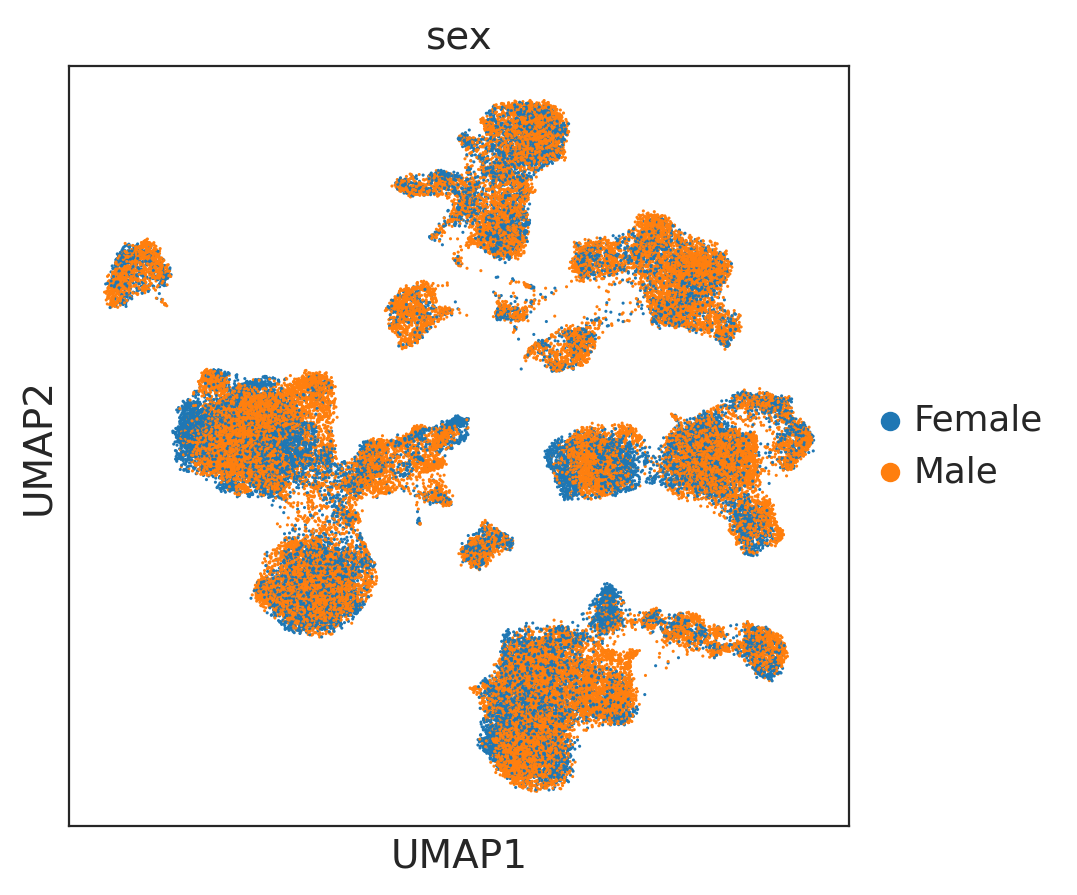

In [8]:
sc.pl.umap(adata, color = ["sex"], size=5)

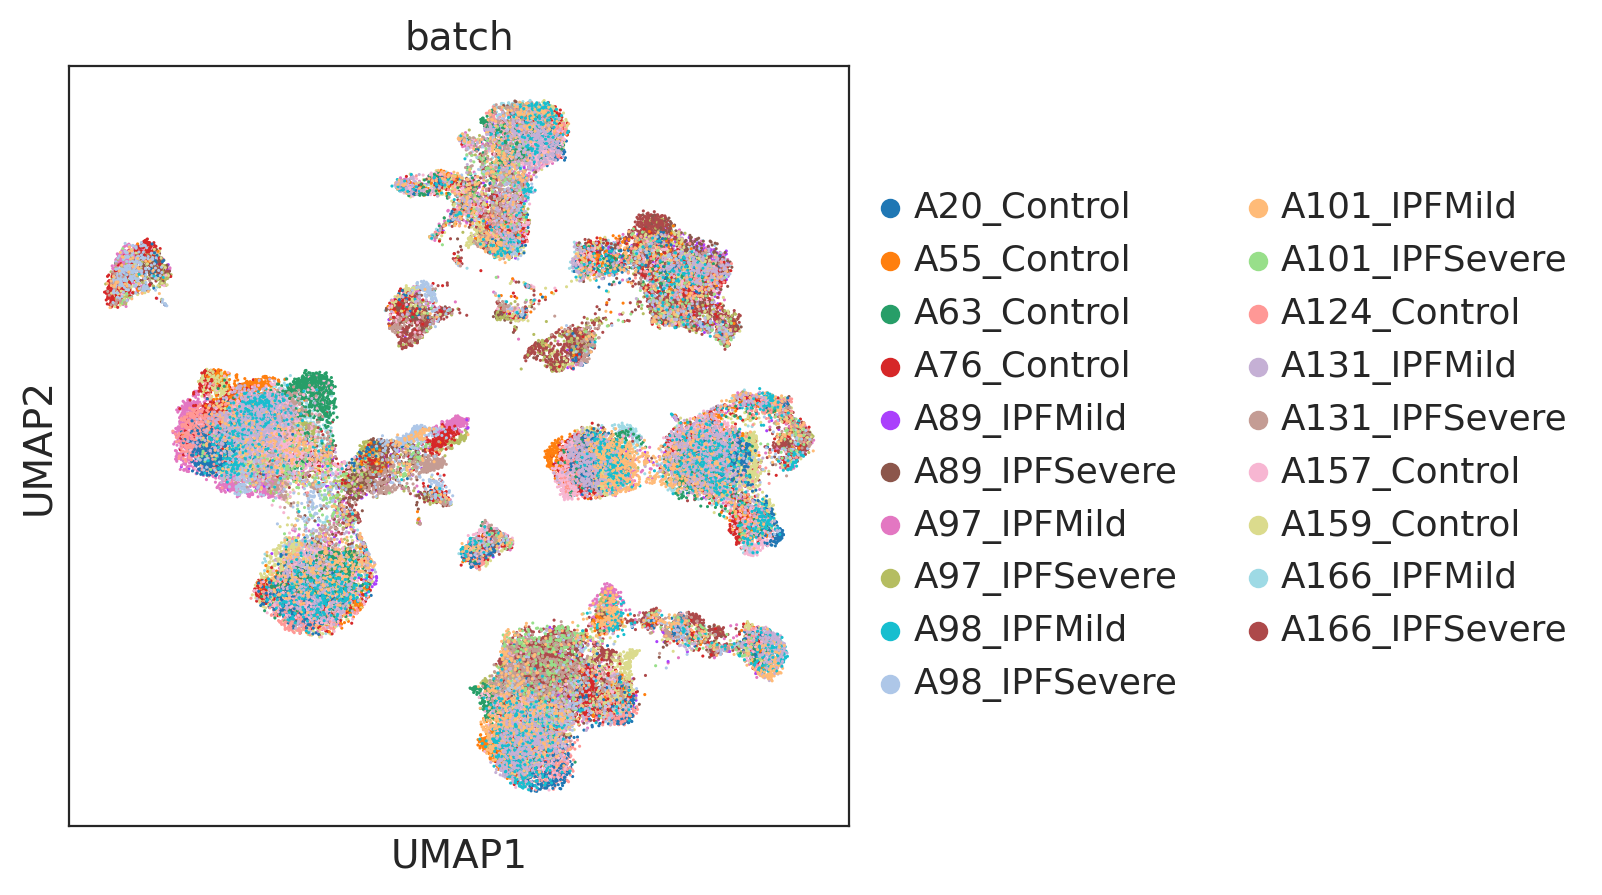

In [9]:
sc.pl.umap(adata, color = ["batch"], size=5)

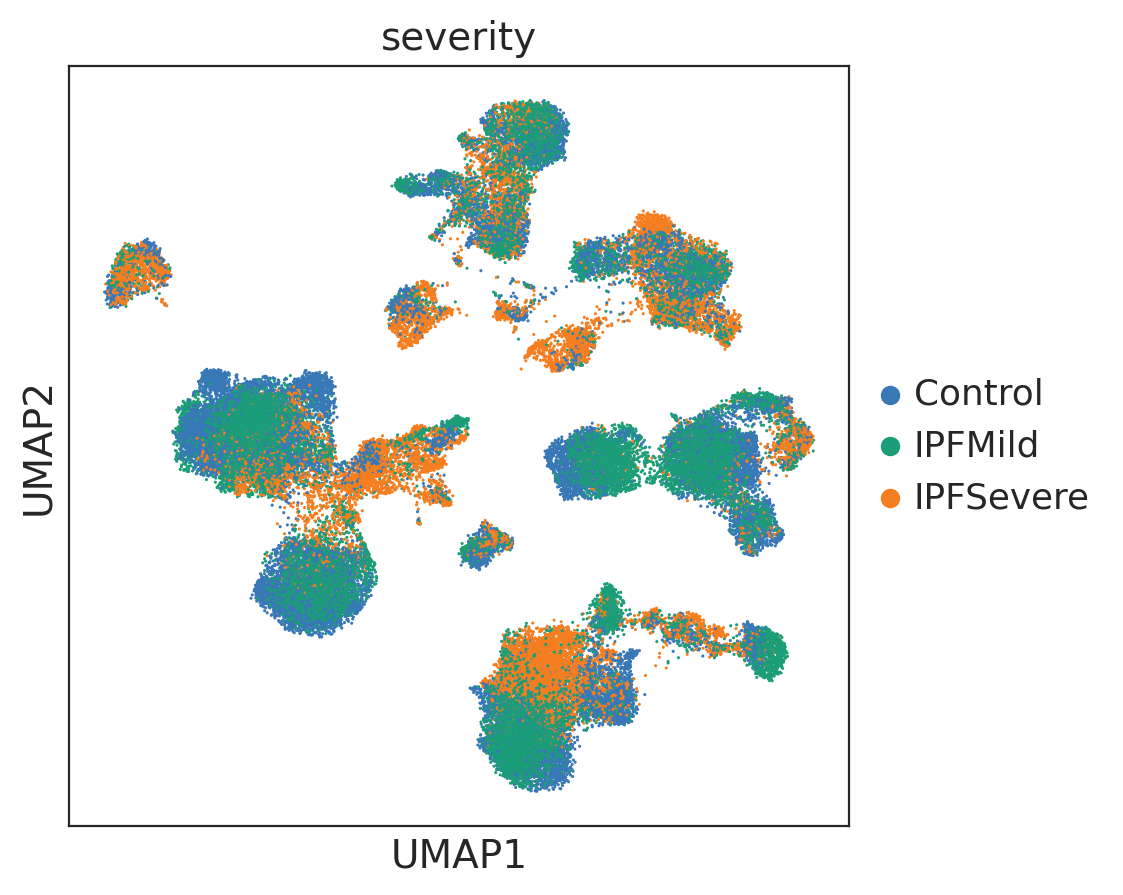

In [10]:
sc.pl.umap(adata, color = ["severity"], size=5)

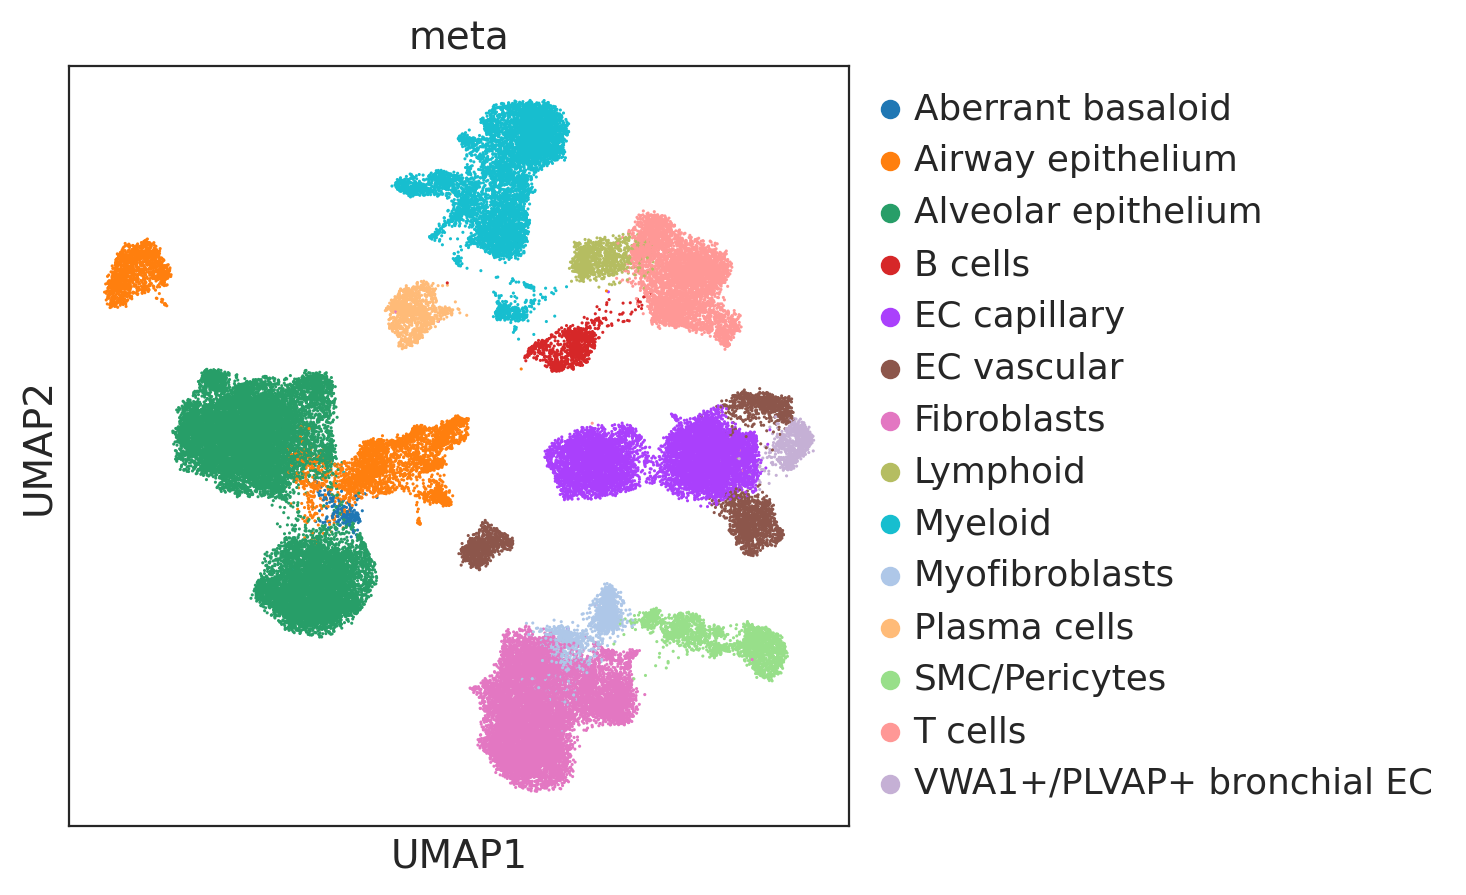

In [11]:
sc.pl.umap(adata, color = ["meta"], frameon= True, size = 5)

In [12]:
adata.obs["batch"] = adata.obs["name"].copy()
xlabel = "severity"
ct_label = "cell_type"
cols = adata.uns[f"{ct_label}_colors"]
order = adata.obs[xlabel].cat.categories.values
celltypes = adata.obs[ct_label].cat.categories

# sample-level relative frequencies
relFreqs = calc_relFreq(adata, group_by = ct_label , xlabel = xlabel, condition=None) 
relFreqs.head(10)

,AT1,AT2,Aberrant basaloid,Basal,Ciliated,Goblet,Club,gCap,aCap,LEC,...,cMono,ncMono,B cells,Plasma cells,CD4 T cells,CD8 T cells,T cells proliferating,NK cells,Mast cells,severity
A101_IPFMild,0.092426,0.094761,0.005005,0.002336,0.012679,0.019686,0.007007,0.104771,0.146146,0.011011,...,0.008008,0.006006,0.003337,0.001668,0.028695,0.008008,0.000334,0.013680,0.001001,IPFMild
A101_IPFSevere,0.007187,0.113963,0.046201,0.003080,0.005133,0.034908,0.026694,0.013347,0.002053,0.020534,...,0.003080,0.000000,0.012320,0.006160,0.067762,0.022587,0.001027,0.001027,0.004107,IPFSevere
A124_Control,0.113682,0.248491,0.000000,0.000000,0.000000,0.000000,0.001509,0.120724,0.071932,0.011569,...,0.005030,0.006539,0.000503,0.001509,0.037223,0.003521,0.000000,0.011066,0.002012,Control
A131_IPFMild,0.088889,0.206433,0.000585,0.000000,0.000000,0.000000,0.001754,0.148830,0.082749,0.004678,...,0.001170,0.013158,0.001170,0.004386,0.058187,0.003216,0.000877,0.015205,0.000292,IPFMild
A131_IPFSevere,0.024490,0.107029,0.006349,0.008163,0.013152,0.097506,0.073923,0.007710,0.004989,0.010884,...,0.000907,0.000454,0.030385,0.028571,0.034467,0.010884,0.000000,0.002268,0.009977,IPFSevere
A157_Control,0.111442,0.318065,0.000000,0.000000,0.000793,0.000000,0.017648,0.115606,0.044220,0.014277,...,0.003966,0.008923,0.000198,0.004164,0.013087,0.005156,0.000198,0.008328,0.001586,Control
A159_Control,0.166712,0.228167,0.000000,0.000943,0.005795,0.001078,0.005256,0.086388,0.053504,0.011321,...,0.006469,0.004717,0.002695,0.008625,0.044474,0.011456,0.000135,0.015499,0.007817,Control
A166_IPFMild,0.121065,0.151250,0.012658,0.000000,0.000649,0.000325,0.002921,0.095748,0.056800,0.009088,...,0.005193,0.007465,0.001623,0.017202,0.094450,0.027264,0.003570,0.036352,0.002921,IPFMild
A166_IPFSevere,0.005385,0.047725,0.008728,0.003157,0.007799,0.001671,0.025441,0.004457,0.001114,0.012442,...,0.002228,0.000371,0.088208,0.059610,0.151161,0.090808,0.000743,0.007057,0.003343,IPFSevere
A20_Control,0.133274,0.234562,0.000000,0.001333,0.008885,0.003998,0.012883,0.102177,0.066193,0.024878,...,0.004887,0.007108,0.007108,0.004887,0.026211,0.014216,0.000888,0.024434,0.003110,Control


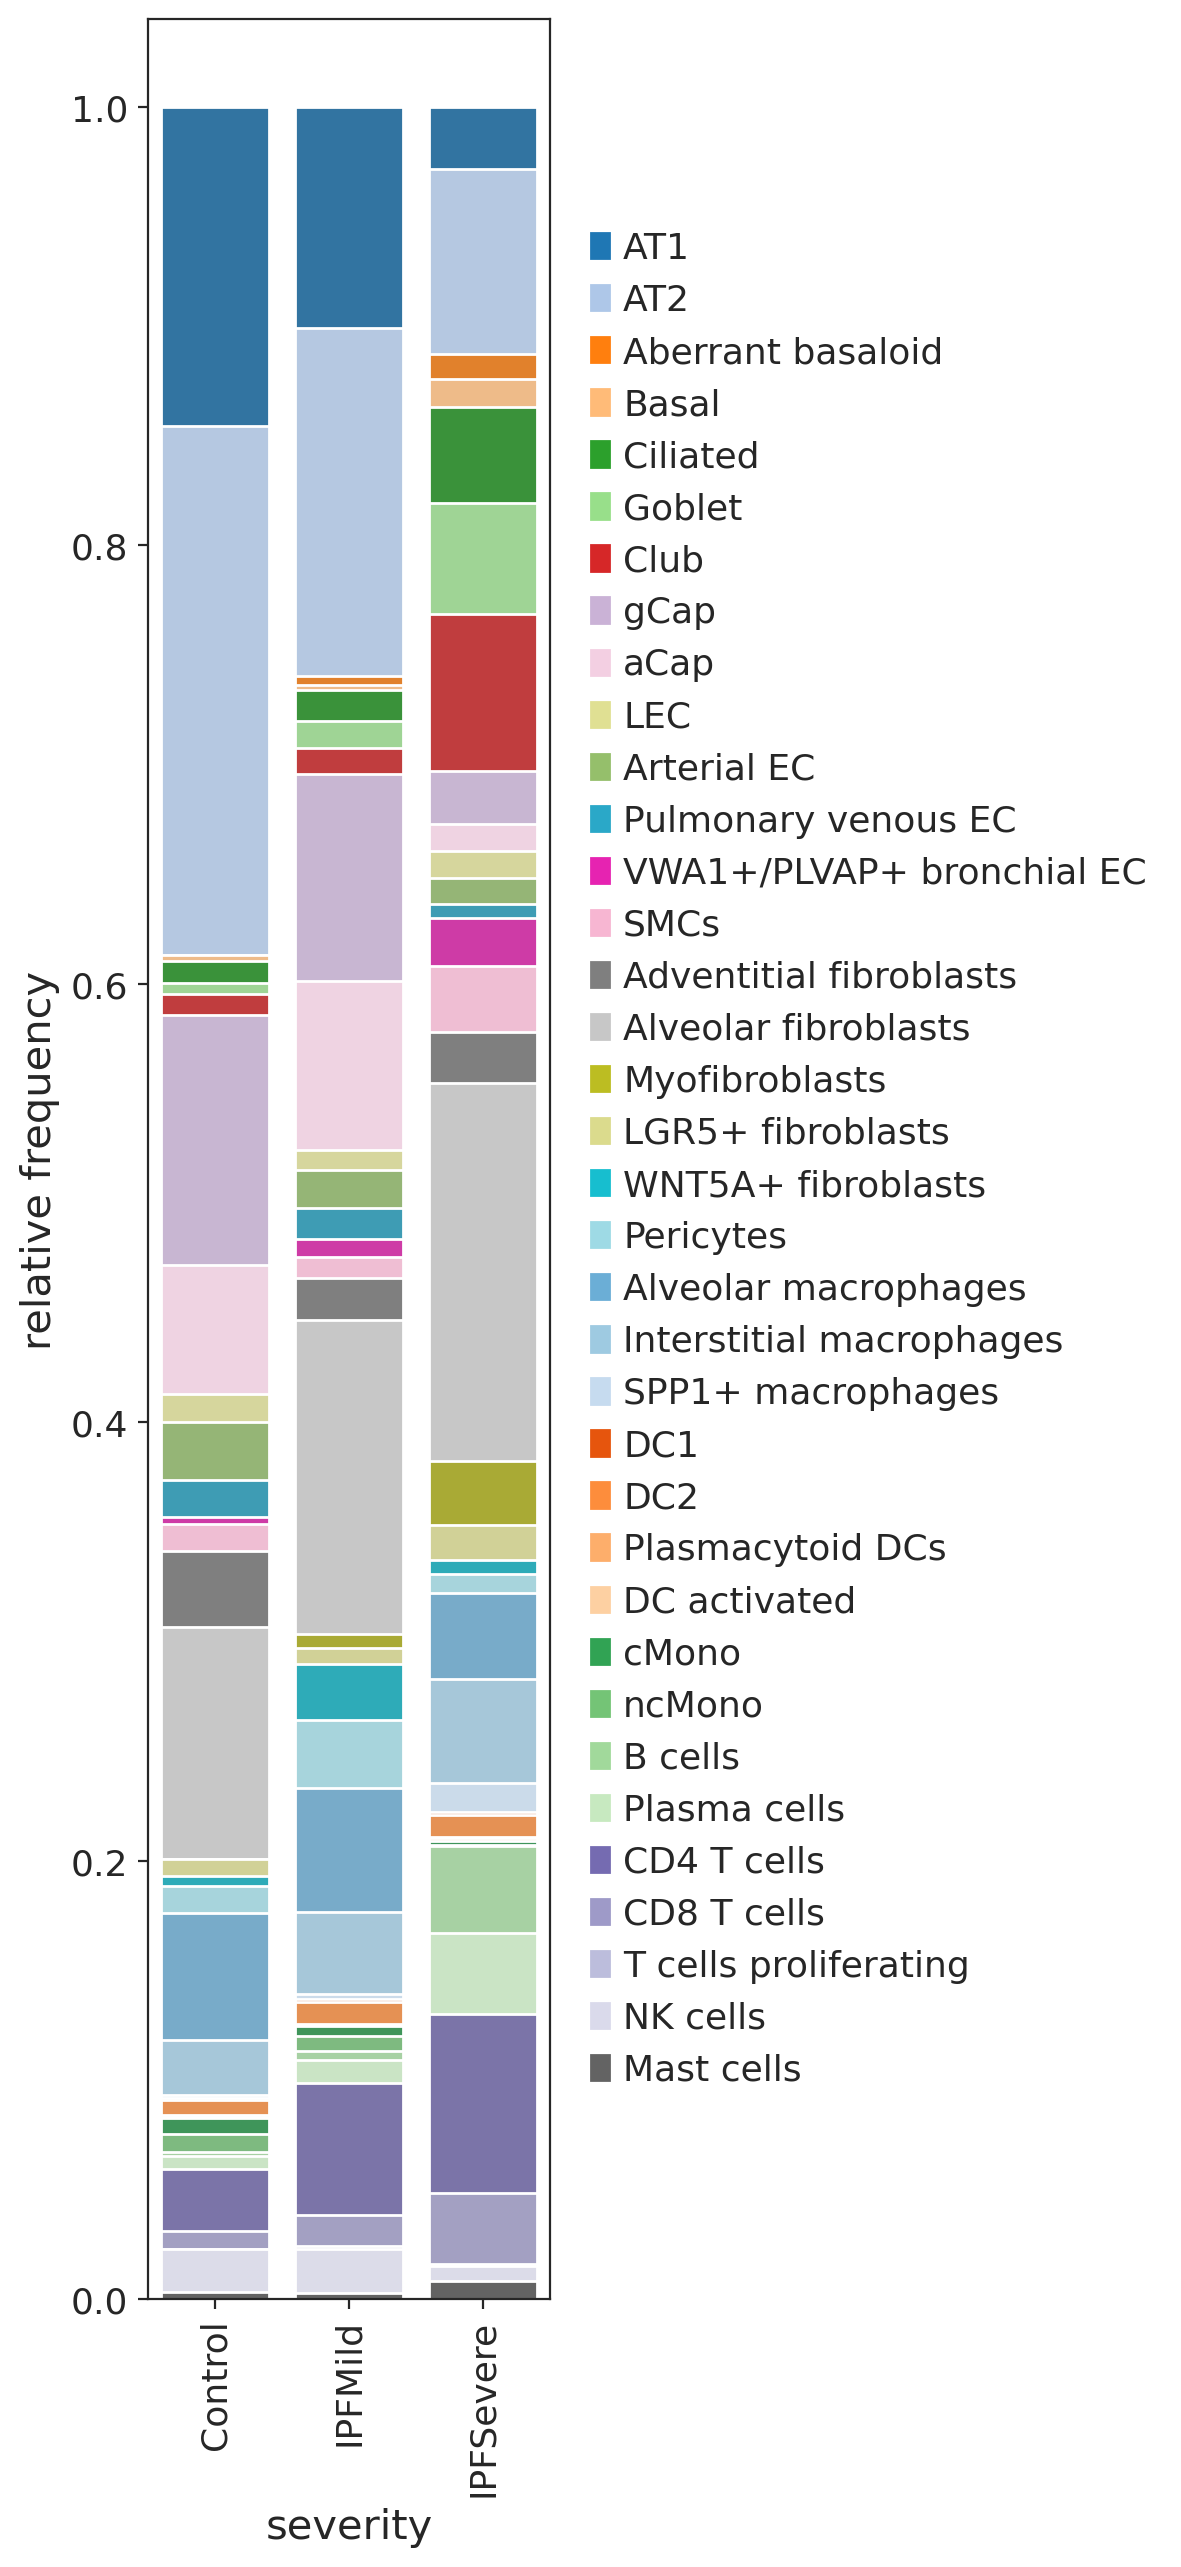

In [13]:
plot_cluster_composition(relFreqs, xlabel = xlabel, figsize = (3, 15), order = ["Control", "IPFMild", "IPFSevere"],
                               errbar = False, cols = cols, width = 0.8)

In [14]:
from matplotlib.colors import LinearSegmentedColormap

gray_red = LinearSegmentedColormap.from_list("gray_red", ["lightgray", "red"])

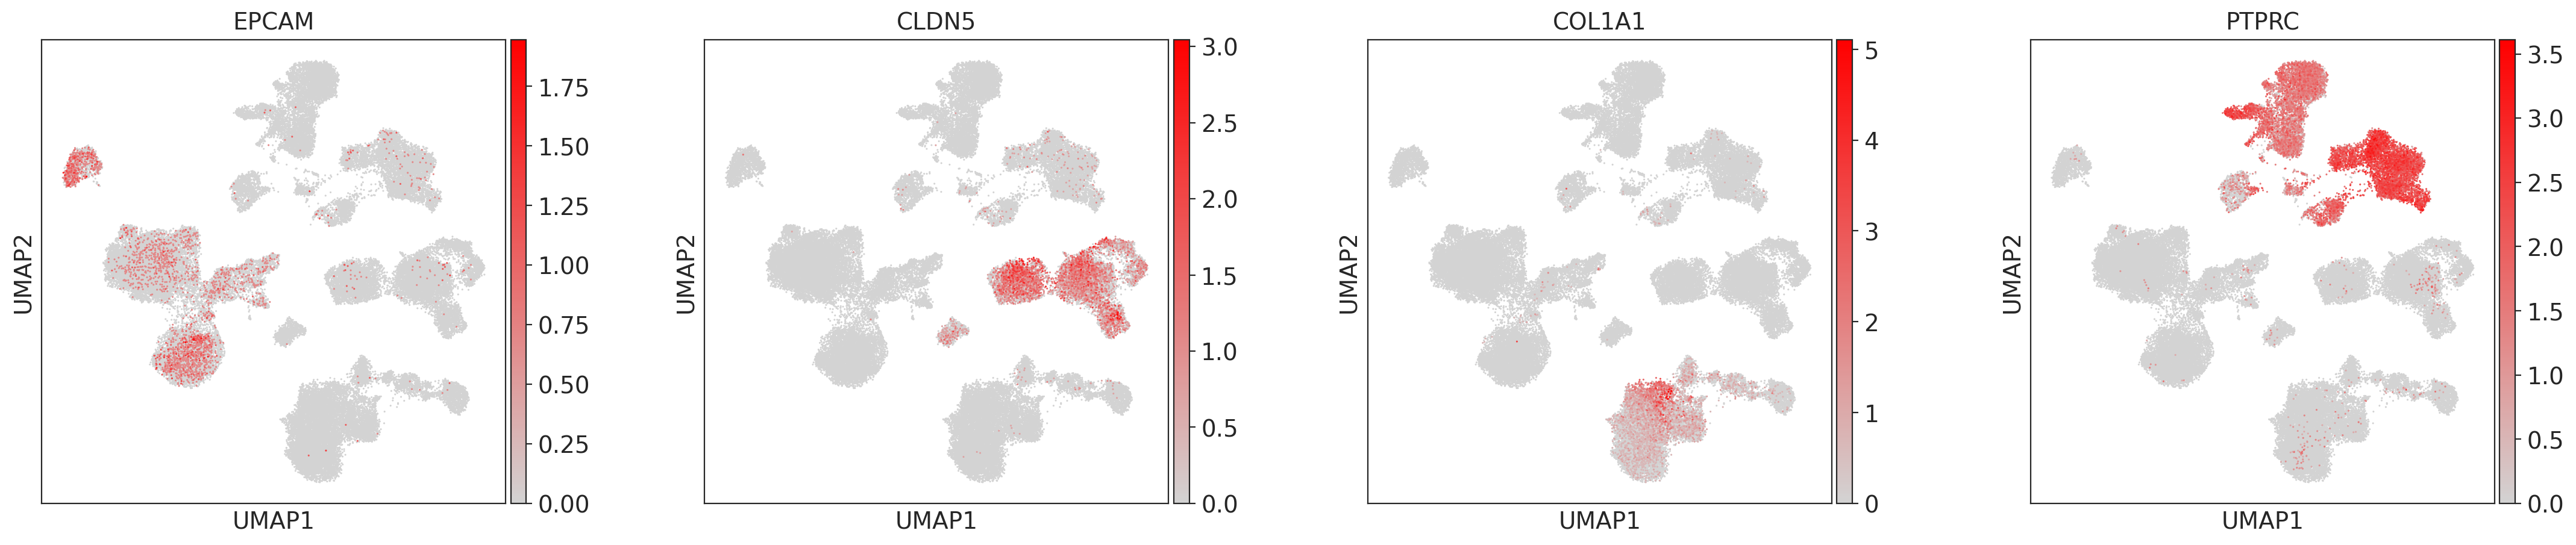

In [15]:
sc.pl.umap(adata, color = ["EPCAM", "CLDN5", "COL1A1", "PTPRC"],
           ncols=4, wspace = 0.3, cmap=gray_red, size=5)

### Subsets

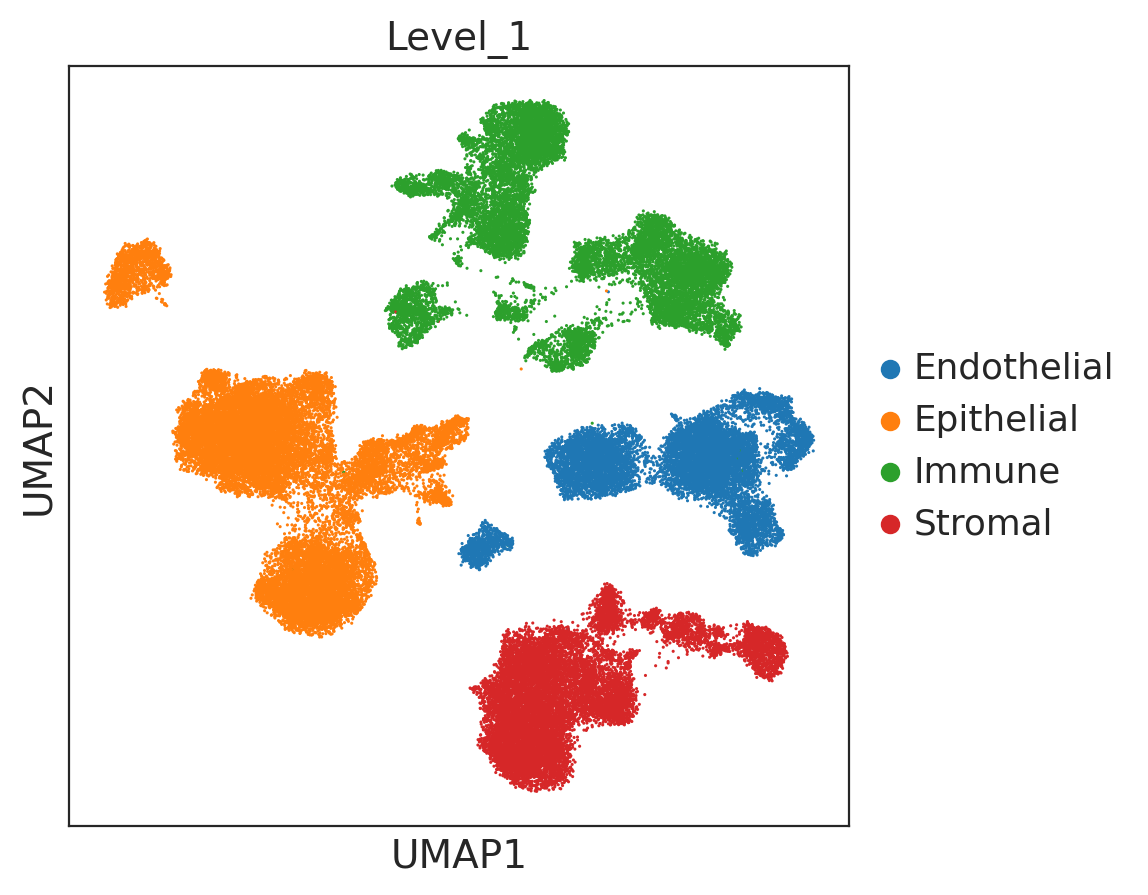

In [16]:
sc.pl.umap(adata, color="Level_1", frameon=True, size = 5)

In [17]:
epi = adata[adata.obs.Level_1.isin(["Epithelial"])].copy()
epi

AnnData object with n_obs × n_vars = 22233 × 31116
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'souporcell_assignment', 'souporcell_singlet_posterior', 'souporcell_doublet_posterior', 'souporcell_log_prob_singleton', 'souporcell_log_prob_doublet', 'souporcell_cluster0', 'souporcell_cluster1', 'souporcell_cluster2', 'ident', 'sum', 'detected', 'subsets_Ribo_sum', 'subsets_Ribo_detected', 'subsets_Ribo_percent', 'total', 'scDblFinder.cluster', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.difficulty', 'scDblFinder.cxds_score', 'scDblFinder.mostLikelyOrigin', 'scDblFinder.originAmbiguous', '_scvi_batch', '_scvi_labels', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'S.Score', 'G2M.Score', 'Phase', 'nCount_SCT', 'nFeature_SCT', 'souporcell_cluster3', 'sex', 'batch', 'Level_1', 'Level_2', 'Level_3', 'cell_type', 'severity', 'name', 'meta', 'ashcroft score', 'fibrosis extent', 'surface density'
    var: 'name', 'highly_variable', 

In [18]:
sc.pp.neighbors(epi, use_rep="X_scVI")
sc.tl.umap(epi) #UMAP is based on scVI embeddings

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:23)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:09)


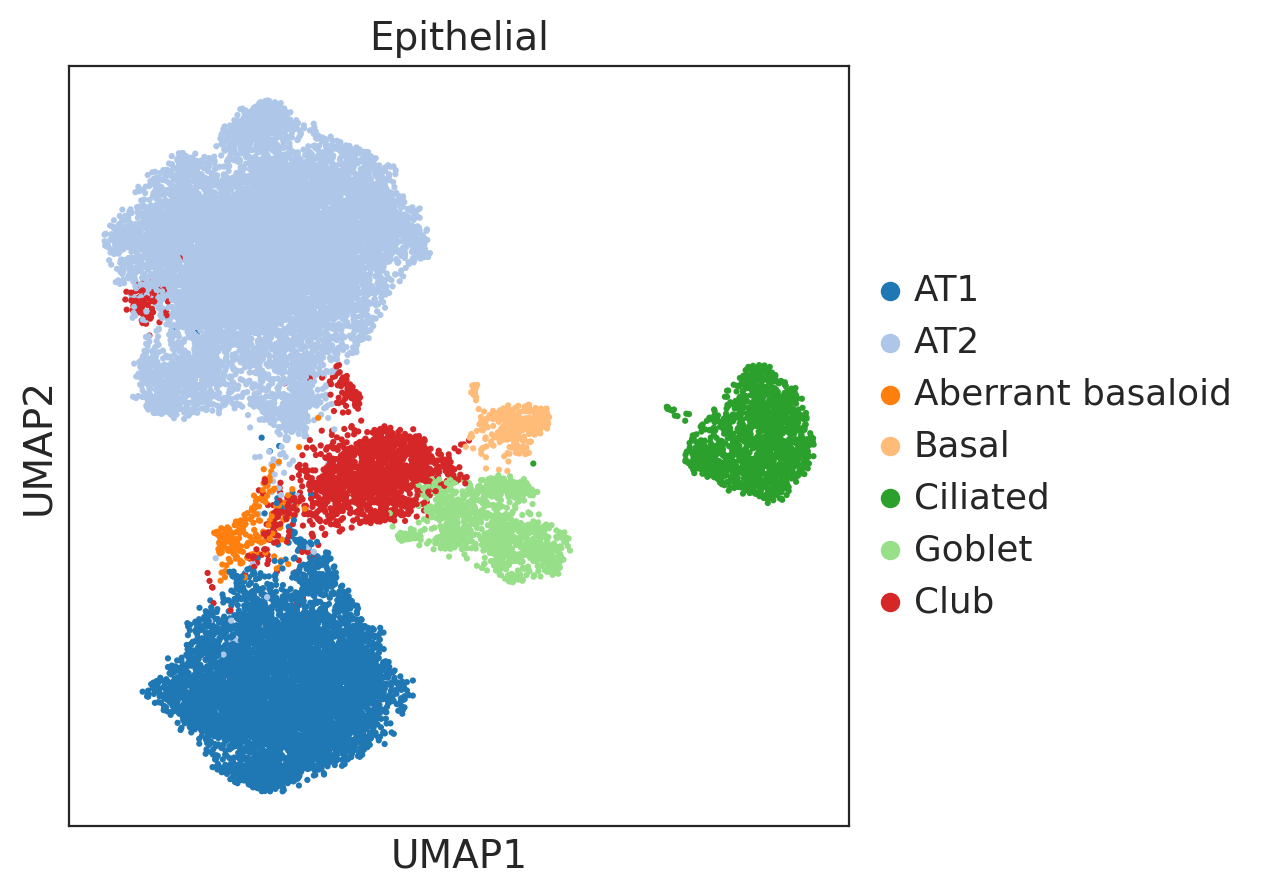

In [19]:
sc.pl.umap(epi, color="cell_type", frameon=True, size=20, title= "Epithelial")

    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_cell_type']`


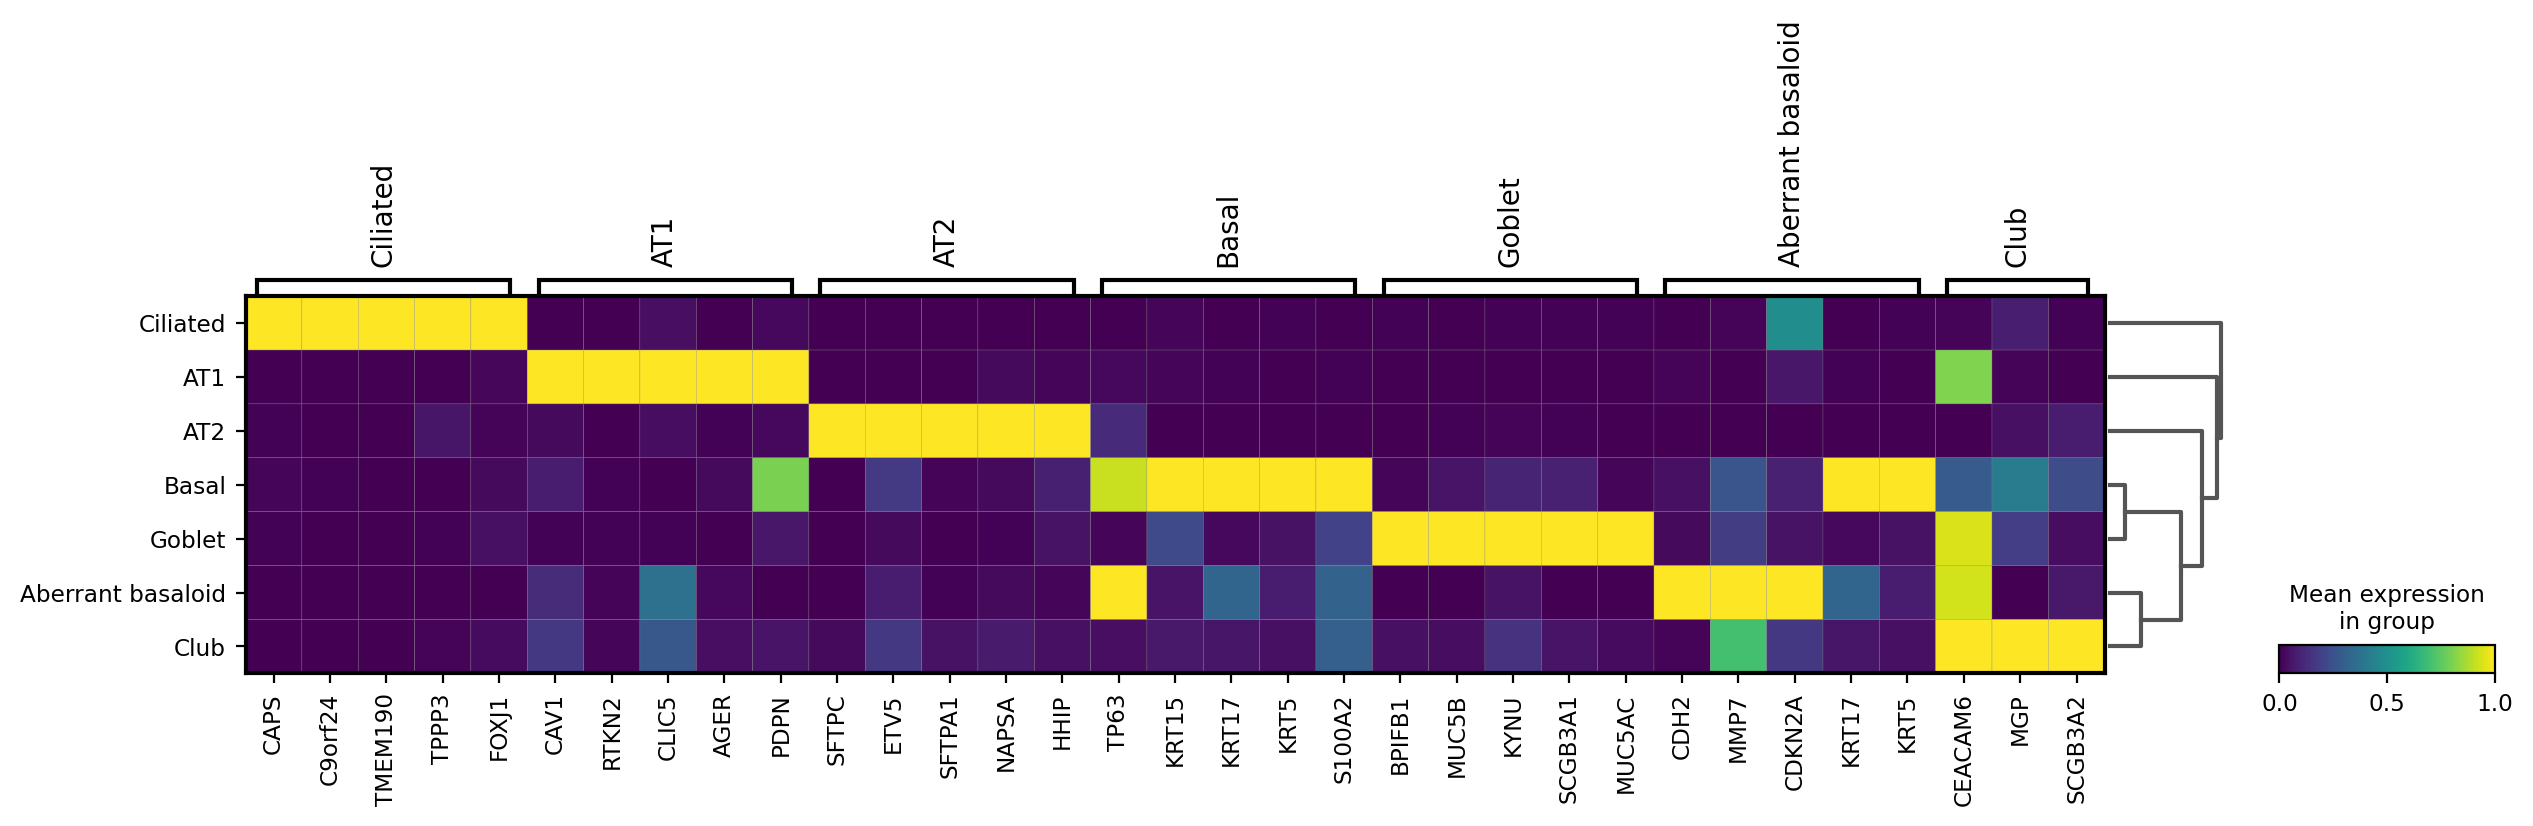

In [20]:
epi_markers={'AT1' : ["CAV1", "RTKN2", "CLIC5", "AGER", "PDPN"], 
                  'AT2' : ["SFTPC", "ETV5", "SFTPA1", "NAPSA", "HHIP"],
                  'Aberrant basaloid' : ["CDH2", "MMP7", "CDKN2A", "KRT17", "KRT5"], 
                  'Basal' : ["TP63", "KRT15", "KRT17", "KRT5", "S100A2"],
                  'Goblet': ["BPIFB1", "MUC5B",  "KYNU", "SCGB3A1", "MUC5AC"],  
                  'Club':["CEACAM6", "MGP", "SCGB3A2"],
                  'Ciliated': ["CAPS", "C9orf24", "TMEM190", "TPPP3", "FOXJ1"]                 
                  }
plt.rcdefaults()
plt.rcParams['pdf.fonttype'] = 42
sc.tl.dendrogram(epi, groupby="cell_type")
sc.pl.matrixplot(epi, var_names=epi_markers, groupby = 'cell_type', dendrogram=True, cmap='viridis', standard_scale='var') 

In [21]:
endo = adata[adata.obs.Level_1.isin(["Endothelial"])].copy()
endo

AnnData object with n_obs × n_vars = 11430 × 31116
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'souporcell_assignment', 'souporcell_singlet_posterior', 'souporcell_doublet_posterior', 'souporcell_log_prob_singleton', 'souporcell_log_prob_doublet', 'souporcell_cluster0', 'souporcell_cluster1', 'souporcell_cluster2', 'ident', 'sum', 'detected', 'subsets_Ribo_sum', 'subsets_Ribo_detected', 'subsets_Ribo_percent', 'total', 'scDblFinder.cluster', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.difficulty', 'scDblFinder.cxds_score', 'scDblFinder.mostLikelyOrigin', 'scDblFinder.originAmbiguous', '_scvi_batch', '_scvi_labels', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'S.Score', 'G2M.Score', 'Phase', 'nCount_SCT', 'nFeature_SCT', 'souporcell_cluster3', 'sex', 'batch', 'Level_1', 'Level_2', 'Level_3', 'cell_type', 'severity', 'name', 'meta', 'ashcroft score', 'fibrosis extent', 'surface density'
    var: 'name', 'highly_variable', 

In [22]:
sc.pp.neighbors(endo, use_rep="X_scVI")
sc.tl.umap(endo) #UMAP is based on scVI embeddings

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:05)


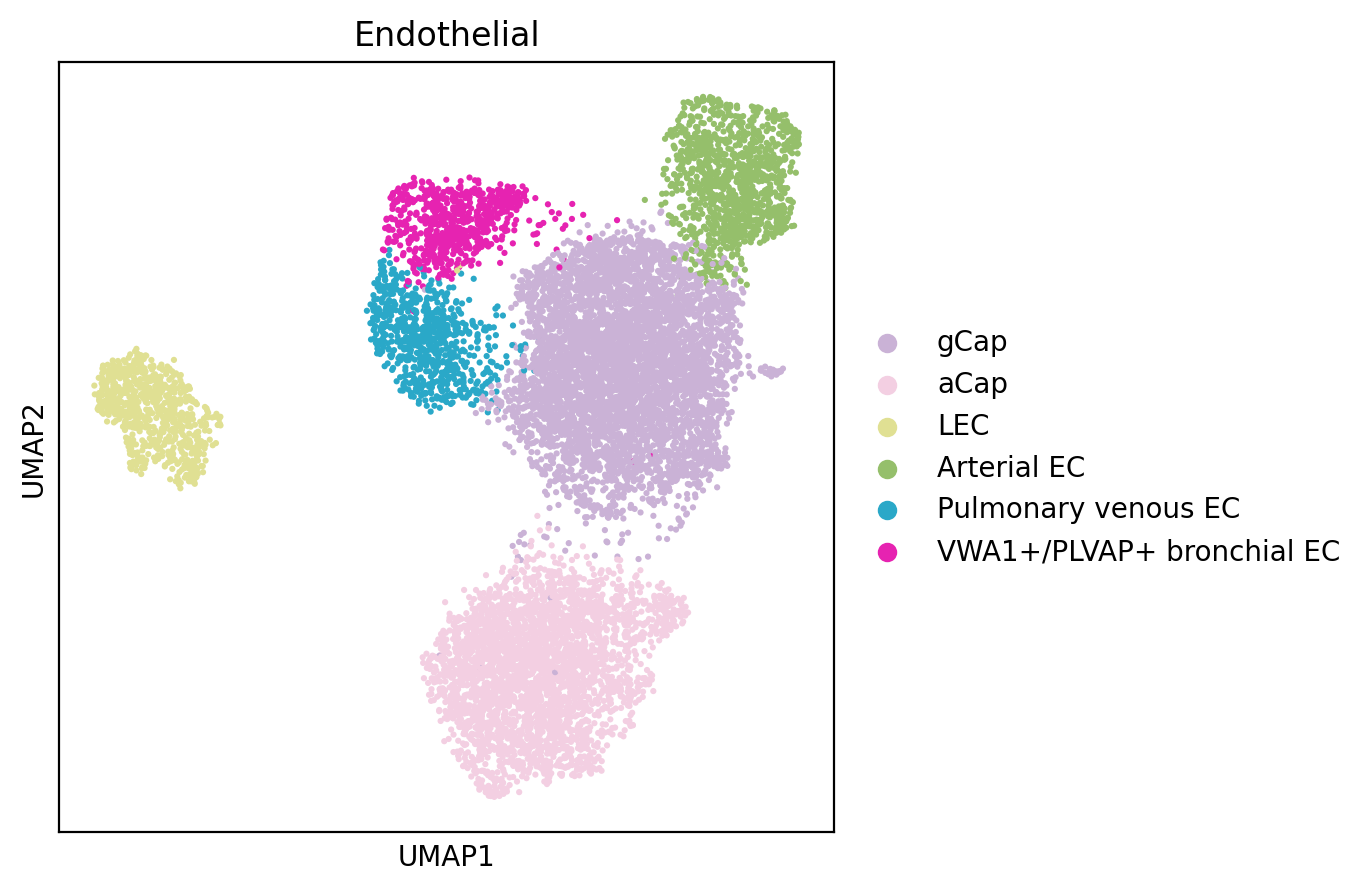

In [23]:
plt.rcParams["figure.figsize"] = (5, 5)
sc.pl.umap(endo, color="cell_type", frameon=True, size=20, title= "Endothelial")

In [24]:
endo.obs["batch"] = endo.obs["name"].copy()
xlabel = "severity"
ct_label = "cell_type"
cols = endo.uns[f"{ct_label}_colors"]
order = endo.obs[xlabel].cat.categories.values
celltypes = endo.obs[ct_label].cat.categories

# sample-level relative frequencies
relFreqs = calc_relFreq(endo, group_by = ct_label , xlabel = xlabel, condition=None) 
relFreqs.head(10)

,gCap,aCap,LEC,Arterial EC,Pulmonary venous EC,VWA1+/PLVAP+ bronchial EC,severity
A101_IPFMild,0.350056,0.488294,0.036789,0.041249,0.055741,0.027871,IPFMild
A101_IPFSevere,0.134021,0.020619,0.206186,0.206186,0.113402,0.319588,IPFSevere
A124_Control,0.409556,0.244027,0.039249,0.107509,0.174061,0.025597,Control
A131_IPFMild,0.568080,0.315848,0.017857,0.039062,0.058036,0.001116,IPFMild
A131_IPFSevere,0.168317,0.108911,0.237624,0.059406,0.148515,0.277228,IPFSevere
A157_Control,0.536339,0.205152,0.066237,0.157314,0.034039,0.000920,Control
A159_Control,0.486343,0.301214,0.063733,0.062974,0.048558,0.037178,Control
A166_IPFMild,0.503413,0.298635,0.047782,0.081911,0.056314,0.011945,IPFMild
A166_IPFSevere,0.060302,0.015075,0.168342,0.133166,0.055276,0.567839,IPFSevere
A20_Control,0.418182,0.270909,0.101818,0.172727,0.034545,0.001818,Control


In [25]:
## Export the relative frequency table
#relFreqs.to_csv(plot_folder + "snRNA_relative_frequencies_severity_EC.csv", index=True)

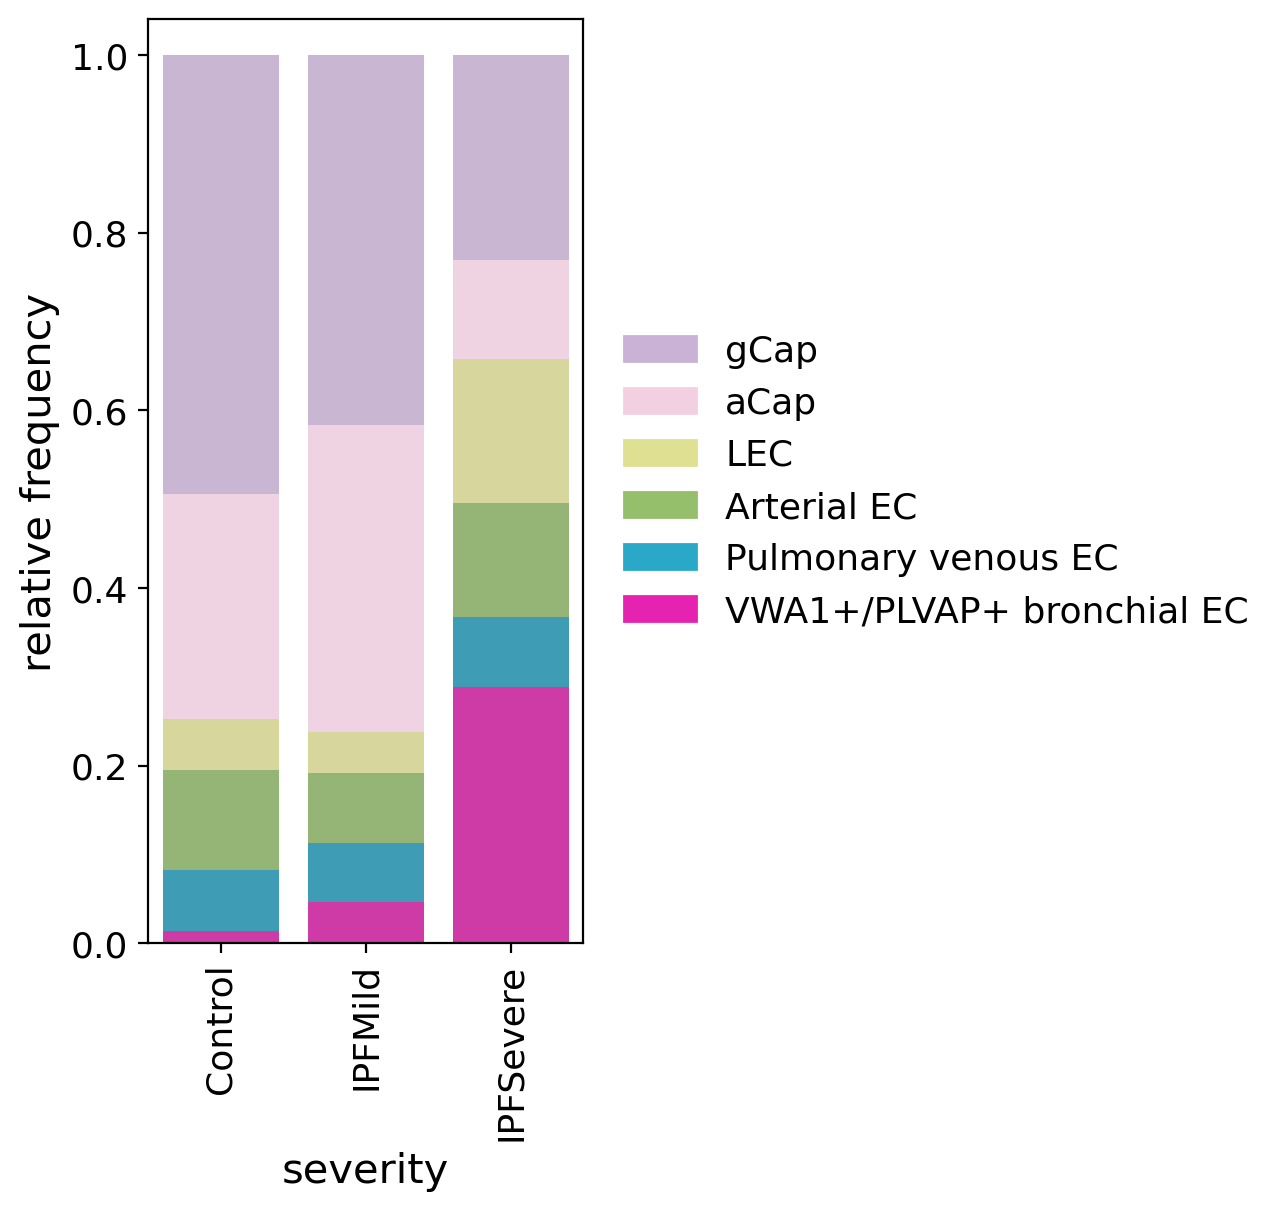

In [26]:
plot_cluster_composition(relFreqs, xlabel = xlabel, figsize = (3, 6), order = ["Control", "IPFMild", "IPFSevere"],
                               errbar = False, cols = cols, width = 0.8)

    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_cell_type']`


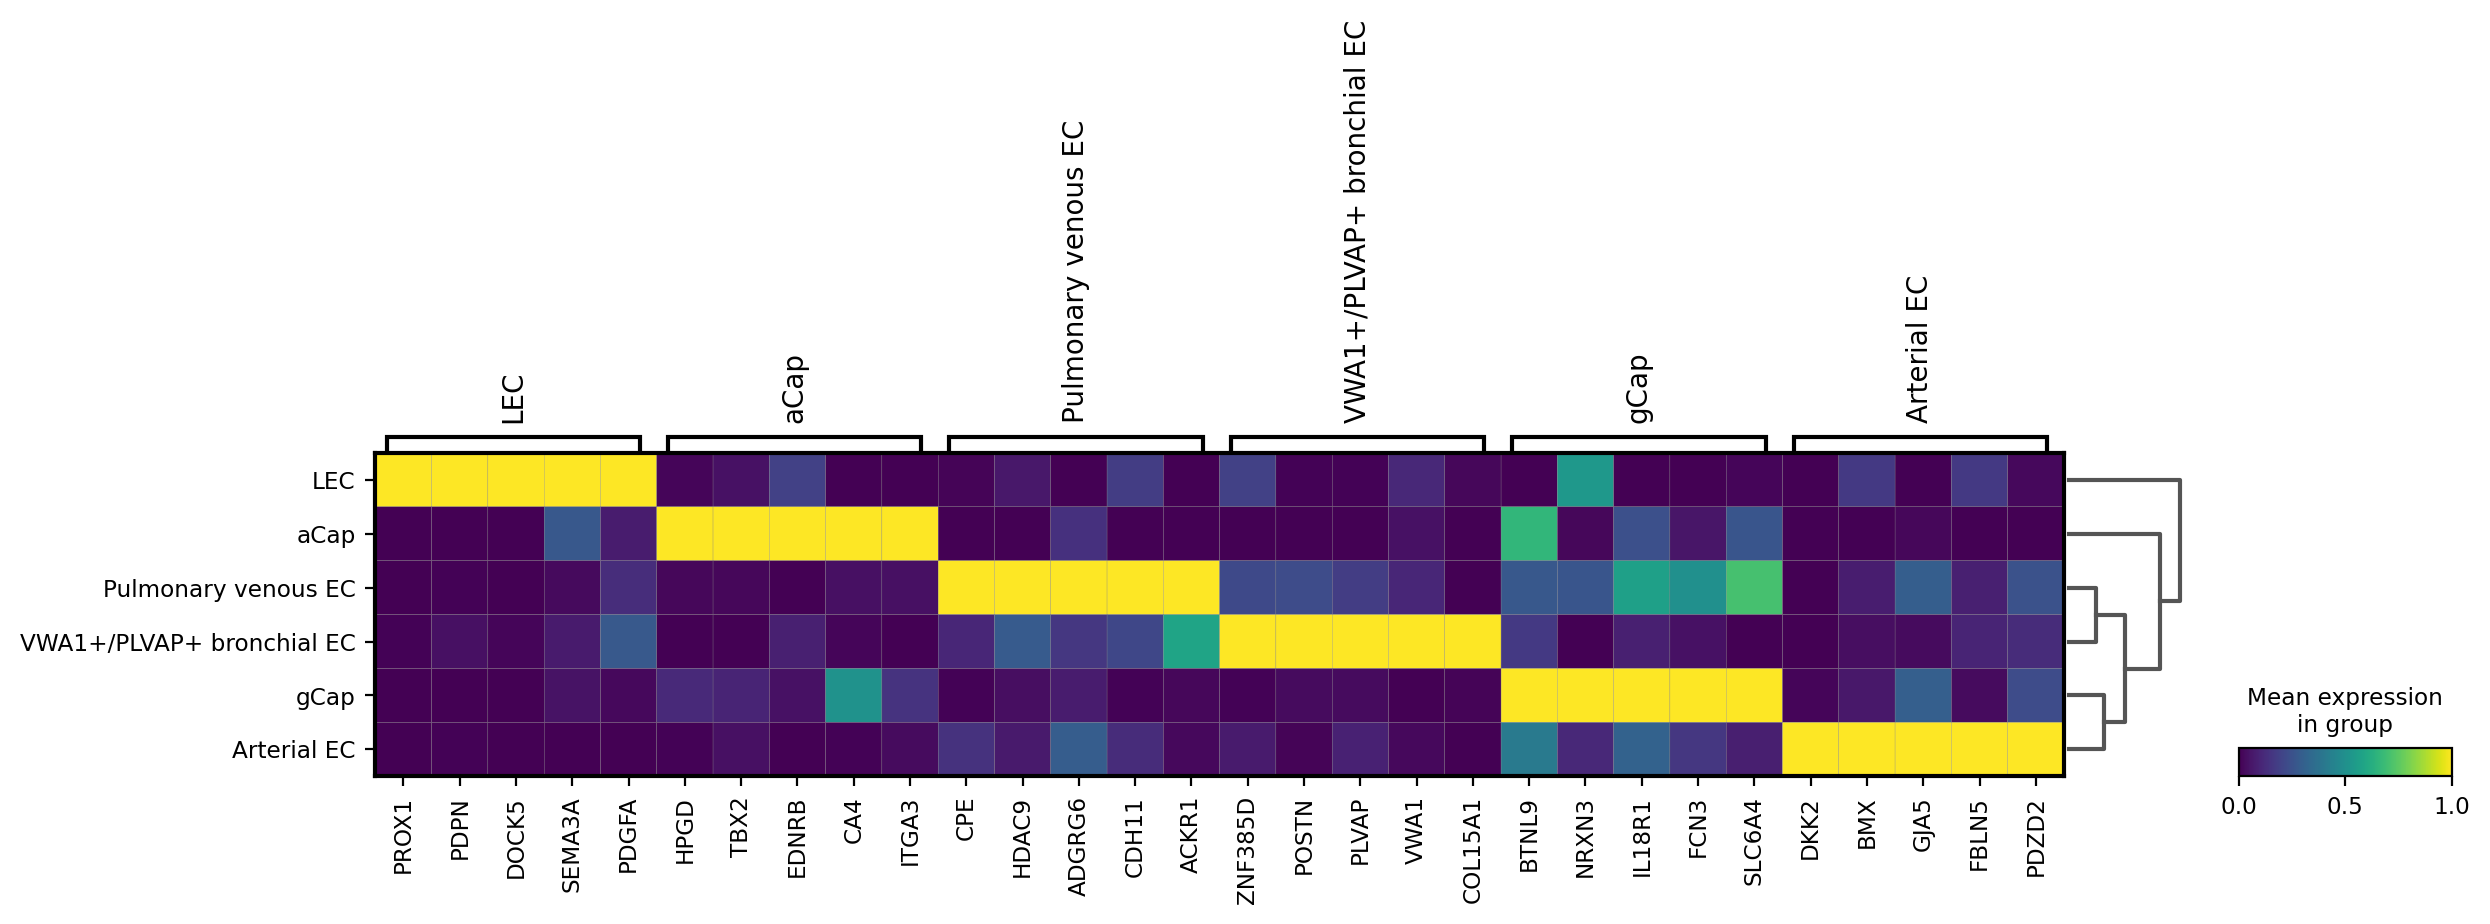

In [40]:
endo_markers={'Arterial EC' : ["DKK2", "BMX", "GJA5", "FBLN5", 'PDZD2'],
                  'gCap' : ["BTNL9", 'NRXN3', 'IL18R1', "FCN3", 'SLC6A4'],
                  'aCap' : ["HPGD", "TBX2", "EDNRB", "CA4", "ITGA3"],
                  'LEC' : ["PROX1", "PDPN", 'DOCK5', 'SEMA3A', 'PDGFA'],
                  'VWA1+/PLVAP+ bronchial EC': ['ZNF385D', 'POSTN', 'PLVAP', 'VWA1', 'COL15A1'], 
                  'Pulmonary venous EC': ['CPE', 'HDAC9', 'ADGRG6','CDH11', 'ACKR1'], 
                  }
plt.rcdefaults()
plt.rcParams['pdf.fonttype'] = 42
sc.tl.dendrogram(endo, groupby="cell_type")
sc.pl.matrixplot(endo, var_names=endo_markers, groupby = 'cell_type', dendrogram=True, cmap='viridis', standard_scale='var') 

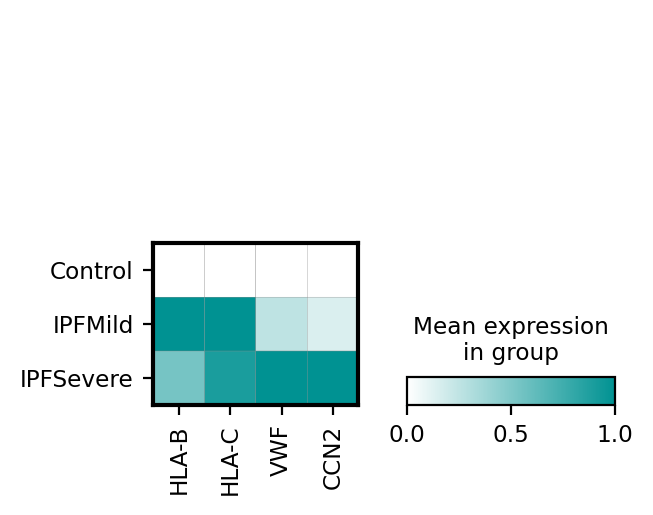

In [28]:
from matplotlib.colors import LinearSegmentedColormap
green_cmap = LinearSegmentedColormap.from_list(
    "green_cmap",
    ["white", "#009292"]
)

plt.rcdefaults()
plt.rcParams['pdf.fonttype'] = 42
sc.pl.matrixplot(
    endo,
    var_names=["HLA-B","HLA-C", "VWF", "CCN2"],
    groupby="severity",
    standard_scale="var",
    cmap=green_cmap,
    #save="GeoMx_CD31_endo_severity_ligands.pdf", 
)

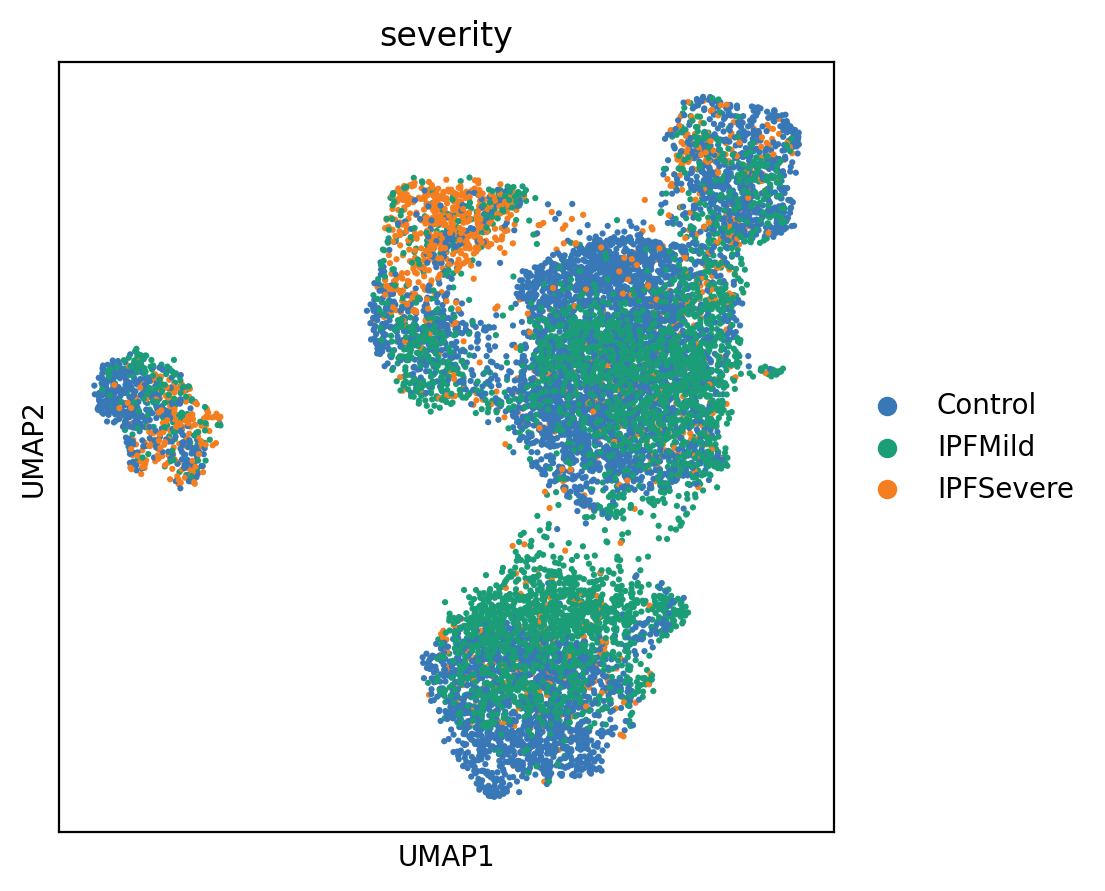

In [29]:
plt.rcParams["figure.figsize"] = (5, 5)
sc.pl.umap(endo, color = ["severity"], size=20)

In [30]:
stromal = adata[adata.obs.Level_1.isin(["Stromal"])].copy()
stromal

AnnData object with n_obs × n_vars = 14420 × 31116
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'souporcell_assignment', 'souporcell_singlet_posterior', 'souporcell_doublet_posterior', 'souporcell_log_prob_singleton', 'souporcell_log_prob_doublet', 'souporcell_cluster0', 'souporcell_cluster1', 'souporcell_cluster2', 'ident', 'sum', 'detected', 'subsets_Ribo_sum', 'subsets_Ribo_detected', 'subsets_Ribo_percent', 'total', 'scDblFinder.cluster', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.difficulty', 'scDblFinder.cxds_score', 'scDblFinder.mostLikelyOrigin', 'scDblFinder.originAmbiguous', '_scvi_batch', '_scvi_labels', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'S.Score', 'G2M.Score', 'Phase', 'nCount_SCT', 'nFeature_SCT', 'souporcell_cluster3', 'sex', 'batch', 'Level_1', 'Level_2', 'Level_3', 'cell_type', 'severity', 'name', 'meta', 'ashcroft score', 'fibrosis extent', 'surface density'
    var: 'name', 'highly_variable', 

In [31]:
sc.pp.neighbors(stromal, use_rep="X_scVI")
sc.tl.umap(stromal) #UMAP is based on scVI embeddings

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:07)


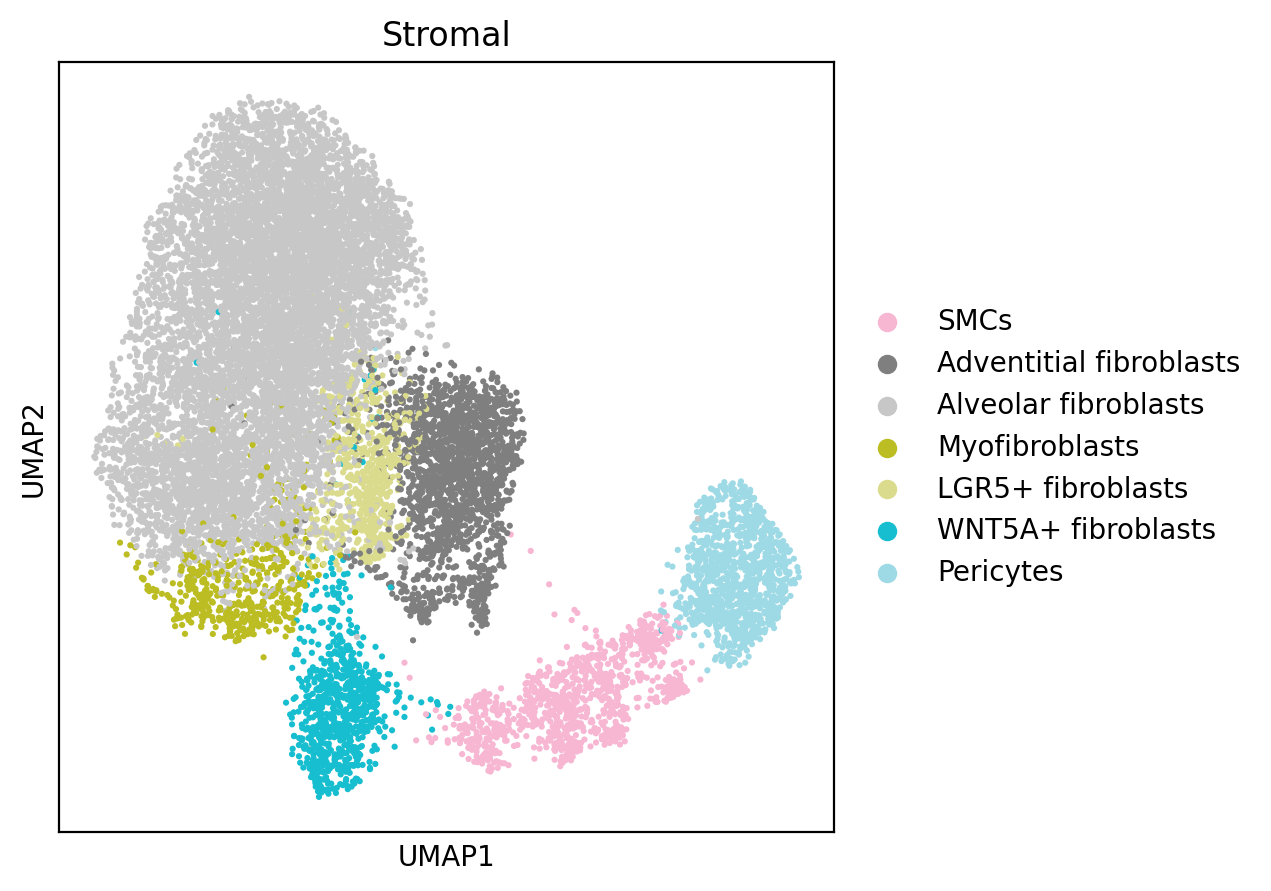

In [32]:
plt.rcParams["figure.figsize"] = (5, 5)
sc.pl.umap(stromal, color="cell_type", frameon=True, size=20, title= "Stromal")

    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_cell_type']`


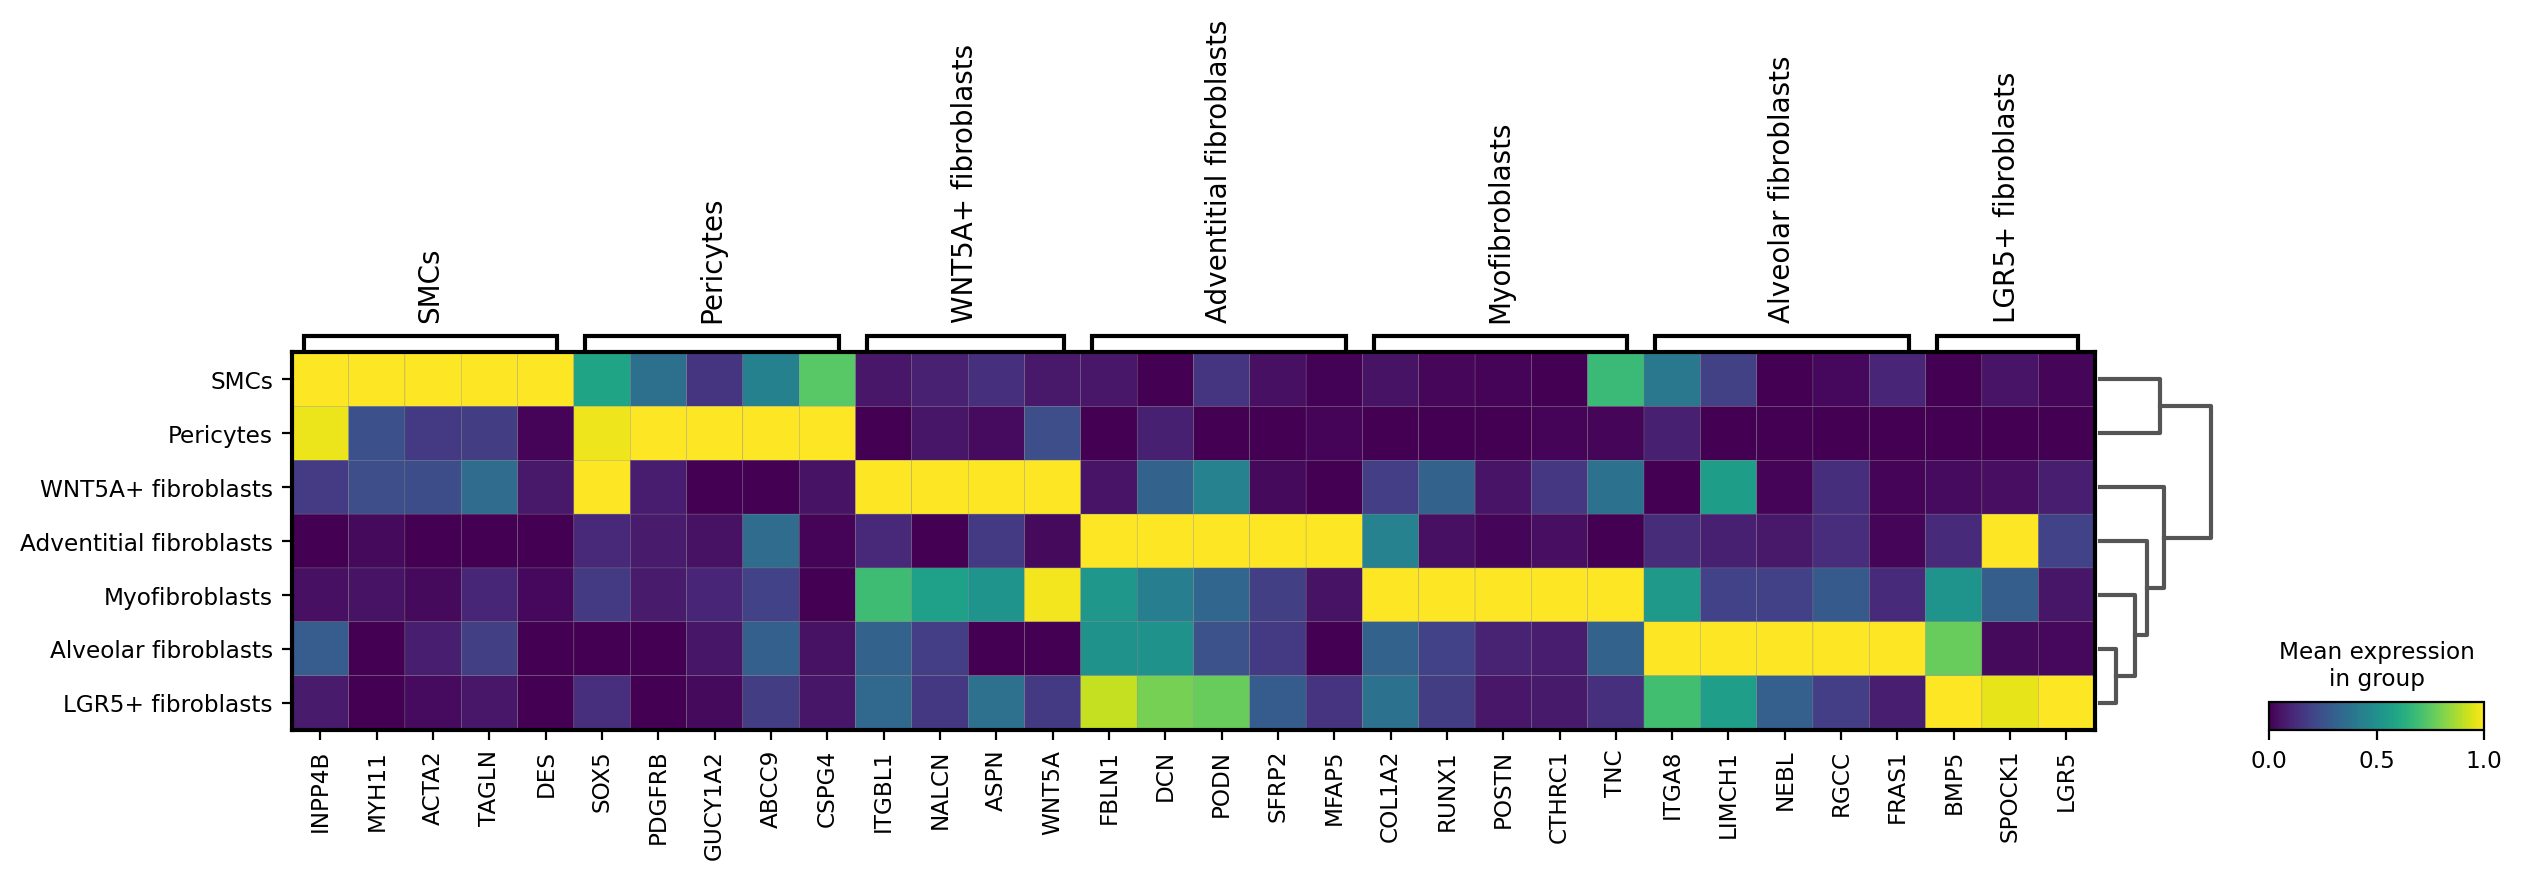

In [43]:
stromal_markers={'Alveolar fibroblasts' : ["ITGA8", "LIMCH1", "NEBL", "RGCC", "FRAS1"],
                  'LGR5+ fibroblasts' : ["BMP5", "SPOCK1", "LGR5"], 
                  'Pericytes' : ["SOX5", "PDGFRB", "GUCY1A2", "ABCC9","CSPG4"], 
                  'WNT5A+ fibroblasts' : ["ITGBL1", "NALCN", "ASPN", "WNT5A"],
                  'Adventitial fibroblasts': ["FBLN1","DCN", "PODN", "SFRP2", "MFAP5"], 
                  'Myofibroblasts':["COL1A2", "RUNX1", "POSTN", "CTHRC1", "TNC"],
                  'SMCs': [ "INPP4B", "MYH11", "ACTA2", "TAGLN", "DES"]                 
                  }

plt.rcdefaults()
plt.rcParams['pdf.fonttype'] = 42
sc.tl.dendrogram(stromal, groupby="cell_type")
sc.pl.matrixplot(stromal, var_names=stromal_markers, groupby = 'cell_type', dendrogram=True, cmap="viridis", standard_scale='var')

In [34]:
gene_categories = {
    "Inflammatory signaling": [
        "HLA-DMB",
        "MIF",
        "IFNG",
        "HLA-C",
        "CD177",
        "SCGB1A1",
    ],

    "ECM remodeling": [
        "COL6A3",
        "DCN",
        "LUM",
        "LAMA2",
        "FBLN1",
        "COL16A1"
    ],

    "Fibrotic signaling": [
        "THBS1",
        "SFRP2",
        "FYN",
    ]
}

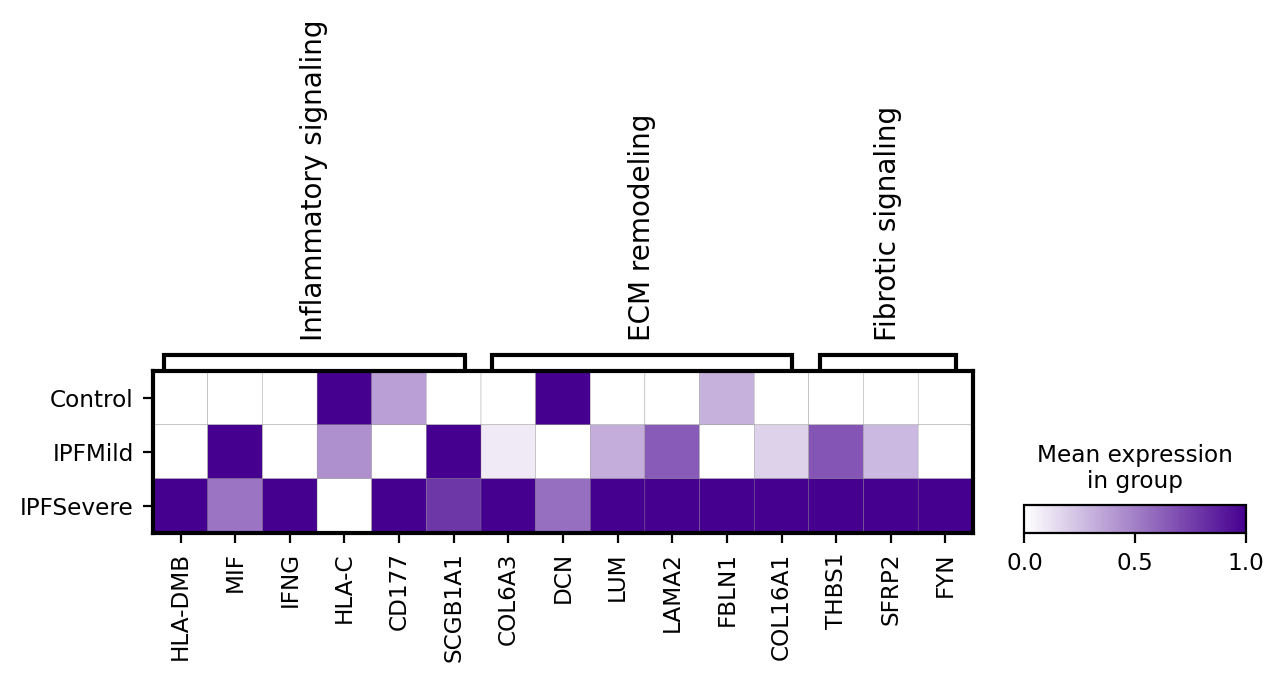

In [35]:
from matplotlib.colors import LinearSegmentedColormap

purple_cmap = LinearSegmentedColormap.from_list(
    "purple_cmap",
    ["white", "#460090"]
)

plt.rcdefaults()
plt.rcParams['pdf.fonttype'] = 42


sc.pl.matrixplot(
    stromal,
    var_names= gene_categories, #"IFNL1", "IFNA13", "LGALS", 
    groupby="severity",
    standard_scale="var",
    cmap=purple_cmap,
    #save = "GeoMx_CD90_fibs_severity_ligands"
)

In [36]:
immu = adata[adata.obs.Level_1.isin(["Immune"])].copy()
immu

AnnData object with n_obs × n_vars = 14989 × 31116
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'souporcell_assignment', 'souporcell_singlet_posterior', 'souporcell_doublet_posterior', 'souporcell_log_prob_singleton', 'souporcell_log_prob_doublet', 'souporcell_cluster0', 'souporcell_cluster1', 'souporcell_cluster2', 'ident', 'sum', 'detected', 'subsets_Ribo_sum', 'subsets_Ribo_detected', 'subsets_Ribo_percent', 'total', 'scDblFinder.cluster', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.difficulty', 'scDblFinder.cxds_score', 'scDblFinder.mostLikelyOrigin', 'scDblFinder.originAmbiguous', '_scvi_batch', '_scvi_labels', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'S.Score', 'G2M.Score', 'Phase', 'nCount_SCT', 'nFeature_SCT', 'souporcell_cluster3', 'sex', 'batch', 'Level_1', 'Level_2', 'Level_3', 'cell_type', 'severity', 'name', 'meta', 'ashcroft score', 'fibrosis extent', 'surface density'
    var: 'name', 'highly_variable', 

In [37]:
sc.pp.neighbors(immu, use_rep="X_scVI")
sc.tl.umap(immu) #UMAP is based on scVI embeddings

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:09)


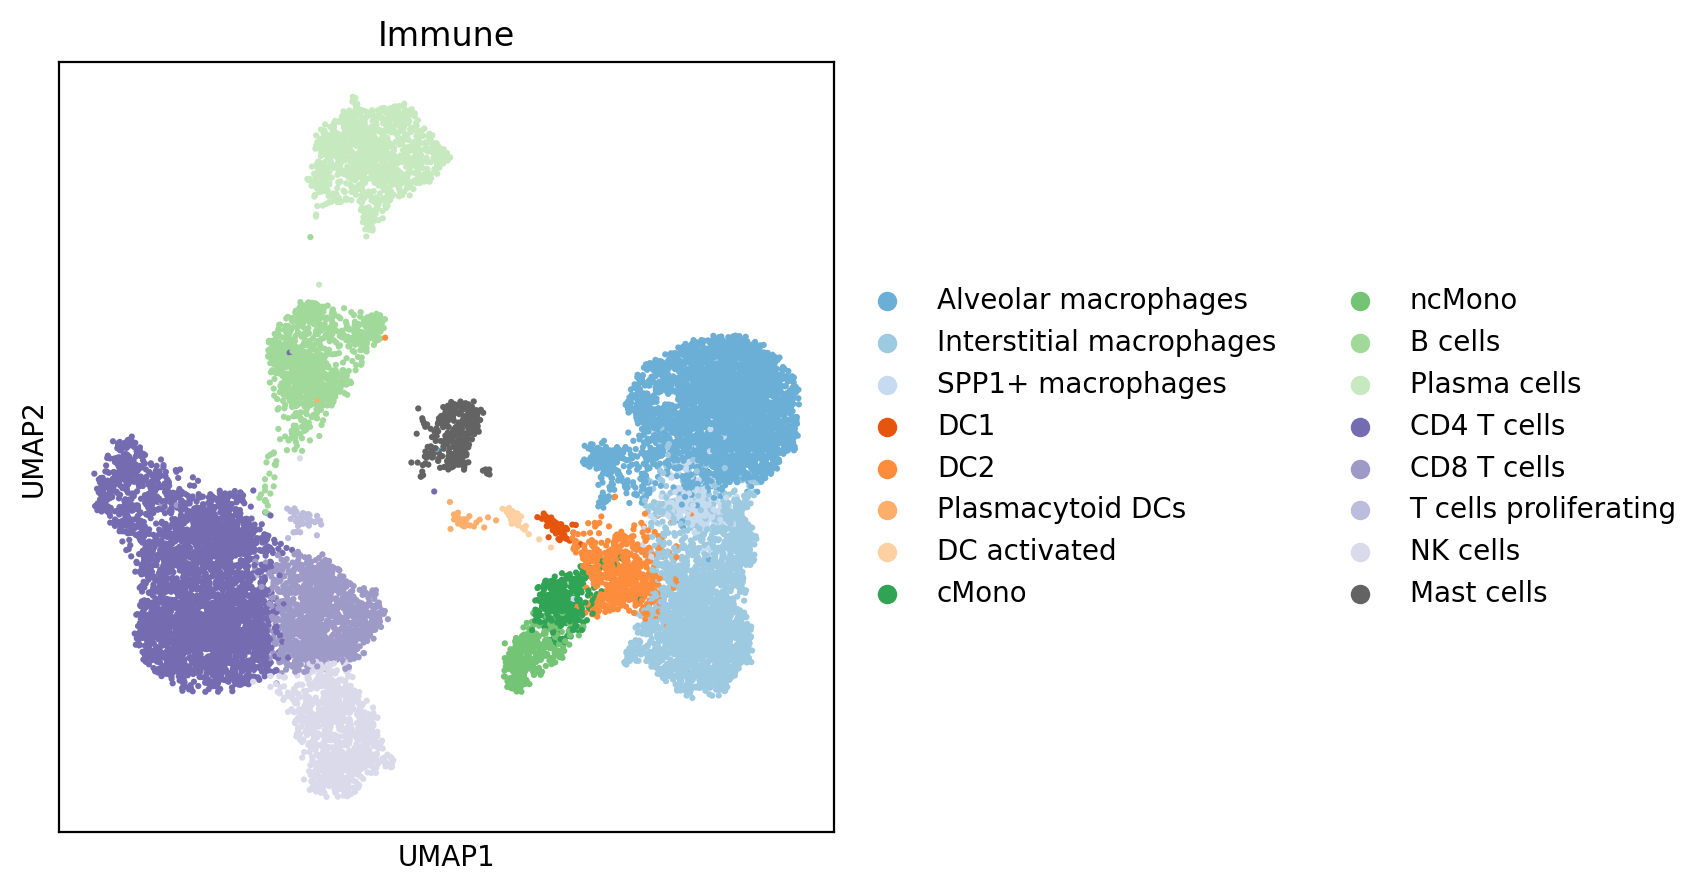

In [38]:
plt.rcParams["figure.figsize"] = (5, 5)
sc.pl.umap(immu, color="cell_type", frameon=True, size=20, title= "Immune")

    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_cell_type']`


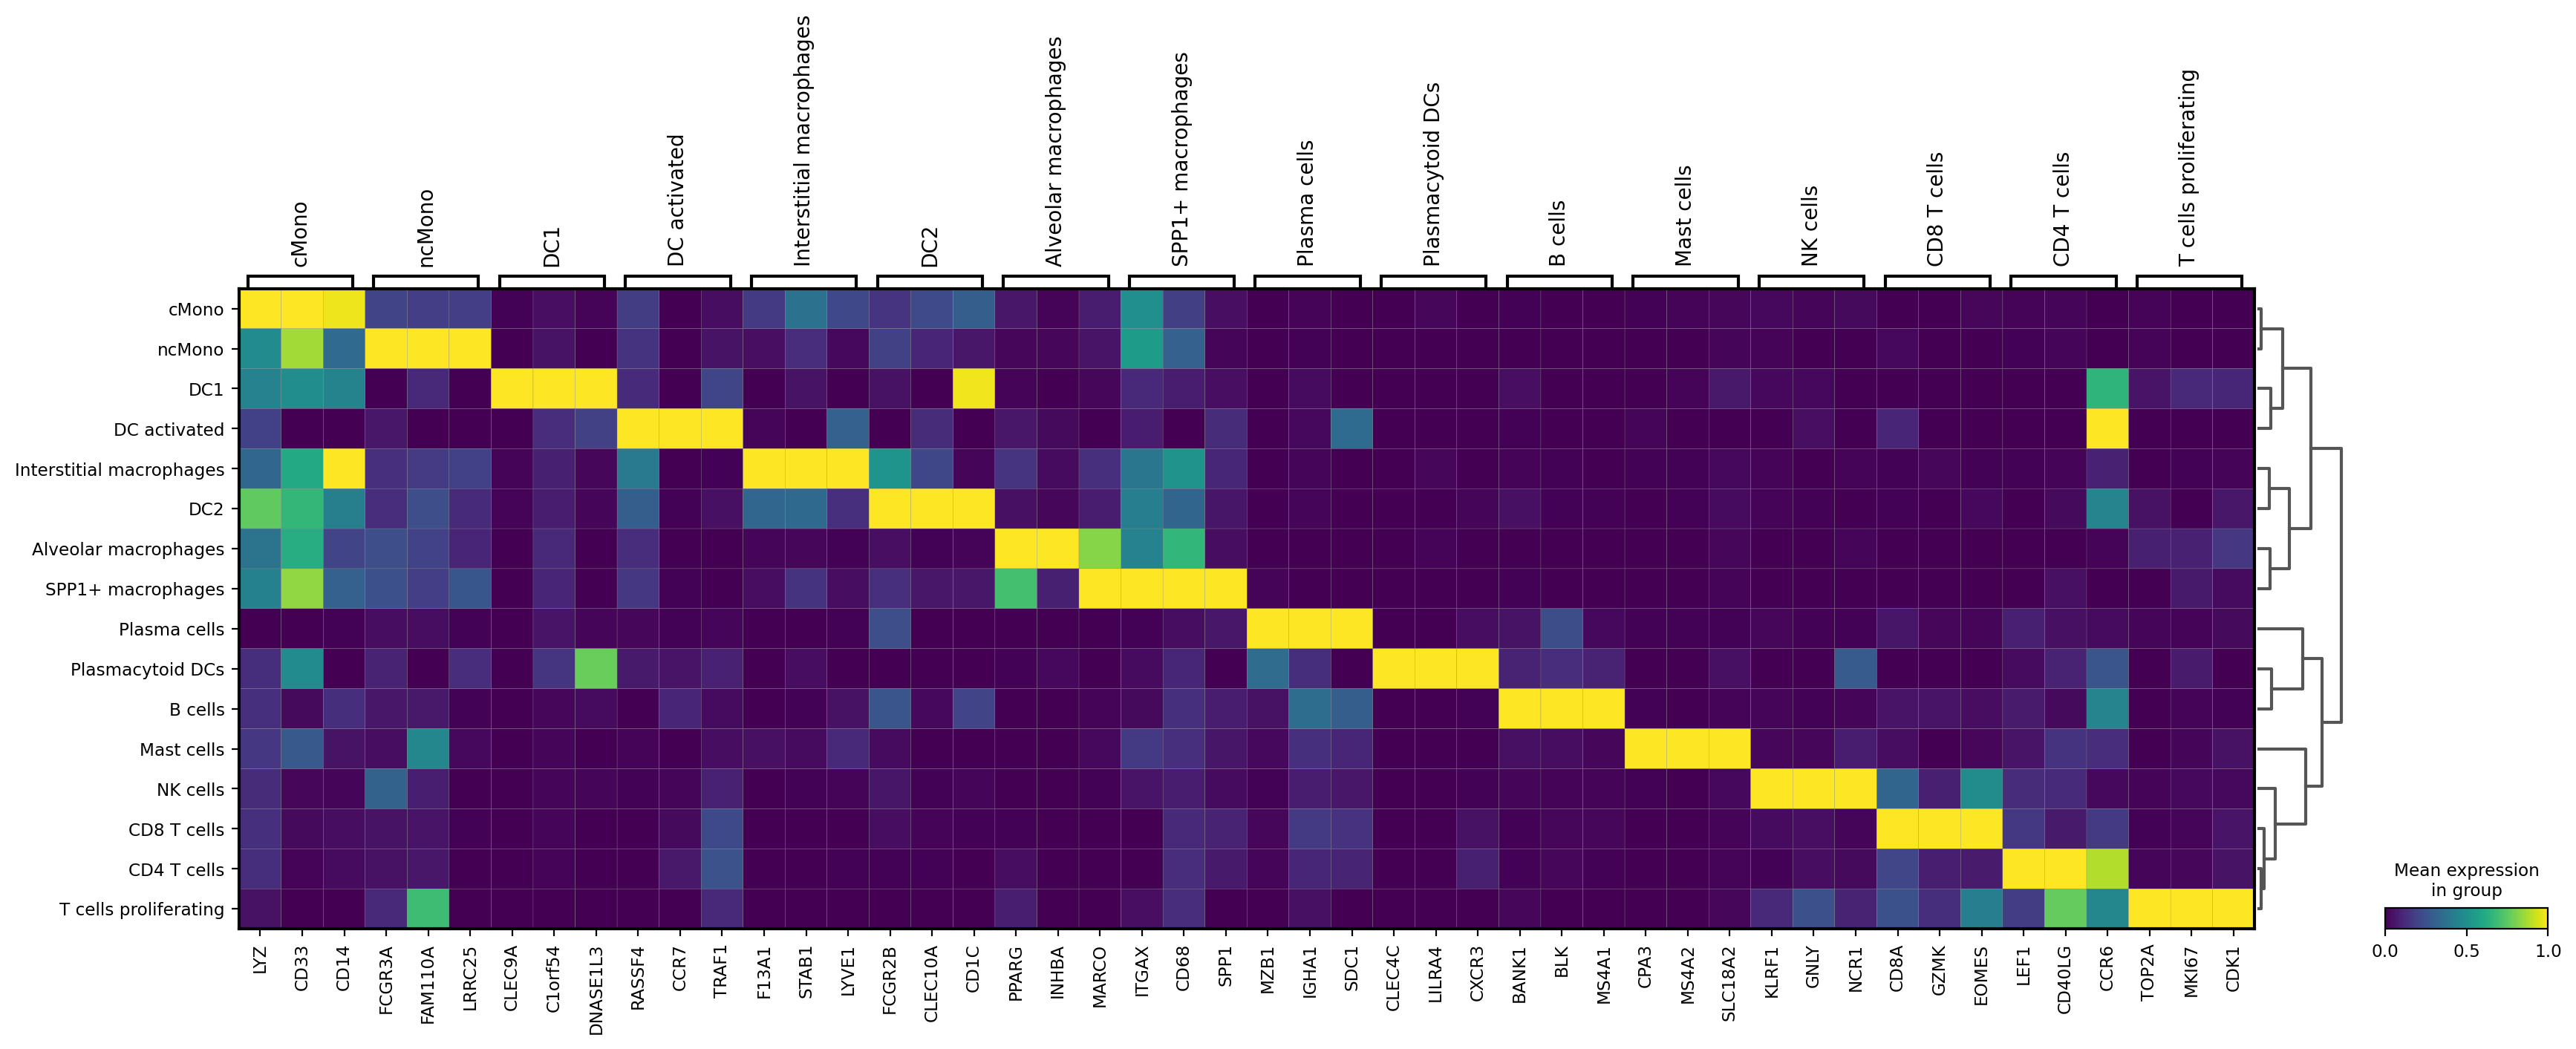

In [39]:
immu_markers={  'cMono': ['LYZ','CD33', 'CD14'],
                'ncMono': ['FCGR3A', 'FAM110A', 'LRRC25'],   
                'DC activated': ['RASSF4', 'CCR7', 'TRAF1'], 
                'DC1': ['CLEC9A', 'C1orf54', 'DNASE1L3'], 
                'DC2':['FCGR2B', 'CLEC10A', 'CD1C'],
                'Plasmacytoid DCs': ['CLEC4C', 'LILRA4', 'CXCR3'],
                'B cells': ['BANK1', 'BLK','MS4A1'],
                'Plasma cells': ['MZB1', 'IGHA1','SDC1'],
                'CD4 T cells': ['LEF1', 'CD40LG','CCR6'],
                'CD8 T cells': ['CD8A','GZMK', 'EOMES'],
                'T cells proliferating': ['TOP2A','MKI67', 'CDK1'],
                'NK cells': ['KLRF1', 'GNLY','NCR1'],
                'Alveolar macrophages': ['PPARG', 'INHBA', 'MARCO'],
                'SPP1+ macrophages': ['ITGAX', 'CD68', 'SPP1'],
                'Interstitial macrophages': ['F13A1', 'STAB1', 'LYVE1'], 
                'Mast cells': ['CPA3', 'MS4A2','SLC18A2'],
              }

plt.rcdefaults()
plt.rcParams['pdf.fonttype'] = 42
sc.tl.dendrogram(immu, groupby="cell_type")
sc.pl.matrixplot(immu, var_names=immu_markers, groupby = 'cell_type', dendrogram=True, cmap="viridis", standard_scale='var') 